In [1]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from mord import OrdinalRidge  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch 
import gzip 
import pickle
from sklearn.preprocessing import StandardScaler

import glob
import os
from scipy.stats import spearmanr, pearsonr

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
import LeafletFA_utilities
importlib.reload(LeafletFA_utilities)

# Import functions from utilities.py 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
from LeafletFA_utilities import *

# check if using cuda device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0
cpu


In [2]:
# Load the original anndata object 
ATSE_anndata_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025/HUMAN_SPLICING_FOUNDATION_Anndata_ATSE_counts_with_waypoints_20250427_121619.h5ad"
print(f"Loading Anndata file: {ATSE_anndata_file}")
splice_adata = ad.read_h5ad(ATSE_anndata_file)
print(f"Anndata file loaded successfully.")

db = gffutils.FeatureDB("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38", keep_order=True)

Loading Anndata file: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025/HUMAN_SPLICING_FOUNDATION_Anndata_ATSE_counts_with_waypoints_20250427_121619.h5ad
Anndata file loaded successfully.


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Identify best model fit

In [3]:
model_outputs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/Leaflet/leafletFAmodel/2025-04-27/"

# Check the specific pattern
run_summary_files = glob.glob(os.path.join(model_outputs, "*", "*run_summary.csv"))

# Read in the run summary files
run_summary = pd.concat([pd.read_csv(f) for f in run_summary_files])

# Remove those with num_epochs == 5 and False waypoints_use, those runs failed 
run_summary = run_summary[run_summary["num_epochs"] > 5]
best_run = run_summary.sort_values(by="best_elbo", ascending=True).iloc[0]
print(run_summary.sort_values(by="best_elbo", ascending=True))

print(f"The best run is {best_run['param_id']} with an ELBO of {best_run['best_elbo']}")

   param_id   K  junc_specific_prior  waypoints_use     best_elbo  input_conc  \
0         3  50                 True           True  3.611258e+08    0.656899   
0         1  50                 True           True  3.639014e+08    0.663072   
0         2  50                 True           True  3.647752e+08    0.566959   
0         0  50                 True           True  3.705069e+08    0.573408   

   num_epochs  num_inits  avg_corr  median_corr  min_corr   lr  num_samples  \
0         150          1       NaN          NaN       NaN  0.8          100   
0         150          1       NaN          NaN       NaN  0.8          100   
0         150          1       NaN          NaN       NaN  0.2          100   
0         150          1       NaN          NaN       NaN  0.2          100   

   ELBO_num_particles  pruned_K  
0                   3        44  
0                   3        50  
0                   3        50  
0                   3        50  
The best run is 3 with an EL

In [4]:
# make a directory into which to save plots and results 
output_dir="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/Leaflet/leafletFAmodel/" 
# combine output_dir with "downstream_analysis" and "date" and create the directory if it does not exist
import datetime
downstream_analysis_dir = os.path.join(output_dir, "downstream_analysis", datetime.datetime.now().strftime("%Y-%m-%d"))
print(f"All plots from this analysis will be saved in {downstream_analysis_dir}")
if not os.path.exists(downstream_analysis_dir):
    os.makedirs(downstream_analysis_dir)
    print(f"Created directory {downstream_analysis_dir}")
else:
    print(f"Directory {downstream_analysis_dir} already exists")

All plots from this analysis will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/Leaflet/leafletFAmodel/downstream_analysis/2025-05-05
Created directory /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/Leaflet/leafletFAmodel/downstream_analysis/2025-05-05


In [5]:
# Define paths
run_outputs = os.path.join(model_outputs, f"run_{best_run['param_id']}")
model_file = os.path.join(run_outputs, "leafletfa_model.pkl.xz")

def load_model(model_file):
    model = {}

    # Detect device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Loading model to device: {device}")

    # Patch torch.load to respect map_location
    def device_load(*args, **kwargs):
        kwargs.setdefault("map_location", device)
        return original_torch_load(*args, **kwargs)

    # Save original and patch
    original_torch_load = torch.load
    torch.load = device_load

    try:
        with gzip.open(model_file, "rb") as f:
            while True:
                try:
                    attr_dict = pickle.load(f)
                    model.update(attr_dict)
                except EOFError:
                    break
    finally:
        torch.load = original_torch_load  # Restore original

    return model


# Load and store the model
leaflet_model = load_model(model_file)

# Debug
print(f"Model loaded successfully from {model_file}")

Loading model to device: cpu
Model loaded successfully from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/Leaflet/leafletFAmodel/2025-04-27/run_3/leafletfa_model.pkl.xz


### Load the gene expression data 

In [6]:
# Load the AnnData
ge_adata = ad.read_h5ad("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_with_NMF_2025-04-27.h5ad")
ge_adata

AnnData object with n_obs × n_vars = 88409 × 30340
    obs: 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type_grouped', 'cell_type', 'broad_cell_type', 'batch', 'cell_id_backup', 'cell_id_index', 'cell_id_clean', 'leiden'
    uns: 'NMF_loadings', 'leiden', 'neighbors_NMF', 'umap'
    obsm: 'X_NMF', 'X_umap'
    layers: 'length_norm', 'log_norm', 'raw_counts'
    obsp: 'neighbors_NMF_connectivities', 'neighbors_NMF_distances'

### Load trained model latent variables

In [7]:
# Extract learned priors variables
alpha_pi = leaflet_model["alpha_pi"] 
bb_conc = leaflet_model["bb_conc"] 
dir_conc = leaflet_model["dir_conc"]

# Cell factor activity vectors 
PHI = leaflet_model["assign_post"]

# Overall contribution of factors to cell population 
PI = leaflet_model["pi"]
K = leaflet_model["K"]

# Factor junction usage priors 
PSI = leaflet_model["psi_learned"] # (K by J)
PSI_df = pd.DataFrame(PSI.T)
PSI_df.columns = [f"Factor_{i}" for i in range(K)]
PSI_df.index = splice_adata.var.index
PSI_df["PSI_variance"] = PSI_df.var(axis=1)
PSI_df["junction_id_index"] = range(PSI_df.shape[0])

# Add imputed junction usage ratios for every cell into anndata 
PSI_CELLS = np.dot(PHI, PSI)

# Add to anndata
splice_adata.layers["PSI_CELLS"] = PSI_CELLS

In [8]:
print(f"The alpha_pi value is {alpha_pi}")
print(f"The dir_conc value is {dir_conc}")
print(f"The bb_conc value is {bb_conc}")

The alpha_pi value is 23.656667709350586
The dir_conc value is 10.733319282531738
The bb_conc value is 0.6568995118141174


In [9]:
# Get posterior samples (sampled from variational distribution / guide)
psi_samples = leaflet_model["psi_samples"]  # [n_samples, K, J]
phi_samples = leaflet_model["psi_samples"]  # [n_samples, C, K]

# Confirm shapes of psi_samples and phi_samples
print(f"psi_samples shape: {psi_samples.shape}")
print(f"phi_samples shape: {phi_samples.shape}")

# move phi_samples and psi_samples to device
phi_samples = phi_samples.clone().detach().to(device=device, dtype=torch.float32)
psi_samples = psi_samples.clone().detach().to(device=device, dtype=torch.float32)

psi_samples shape: torch.Size([100, 44, 23942])
phi_samples shape: torch.Size([100, 44, 23942])


In [10]:
splice_adata

AnnData object with n_obs × n_vars = 88409 × 23942
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type_grouped', 'cell_type', 'broad_cell_type', 'cell_id_index', 'cell_id_clean', 'seqtech'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'splice_motif_score', 'junction_id_index'
    uns: 'neighbors', 'pca_explained_variance_ratio'
    obsm: 'X_pca', 'phi_init_50_waypoints'
    varm: 'psi_init_50_waypoints'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix', 'PSI_CELLS'
    obsp: 'connectivities', 'distances'

### Load list of RBPs and senescence markers!

In [11]:
# RBP file
excel_file = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

# Load the Excel file
rbps = pd.read_excel(excel_file, header=1, index_col=None)
# Rename the first two columns to be gene_name and gene_id 
rbps.rename(columns={rbps.columns[0]: 'gene_name', rbps.columns[1]: 'gene_id'}, inplace=True)

# Convert the gene_name column to capitalize only the first letter and lowercase the rest
rbps['mouse_gene_name'] = rbps['gene_name'].str.capitalize()
print(rbps[['gene_name', 'mouse_gene_name', 'gene_id']].head())

  gene_name mouse_gene_name          gene_id
0      A1CF            A1cf  ENSG00000148584
1      AARS            Aars  ENSG00000090861
2      AATF            Aatf  ENSG00000108270
3     ABCF1           Abcf1  ENSG00000204574
4      ABT1            Abt1  ENSG00000146109


In [12]:
# remove everything after the "." in the gene_id column
splice_adata.var["gene_id"] = splice_adata.var["gene_id"].str.split(".").str[0]
splice_adata.var["RBP_gene"] = splice_adata.var["gene_name"].isin(rbps["gene_name"])

### Add latent variables to anndata 

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Original K is 44 and reduced K is 44


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43],
 [Text(0, 0, '3'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '5'),
  Text(4, 0, '6'),
  Text(5, 0, '9'),
  Text(6, 0, '16'),
  Text(7, 0, '11'),
  Text(8, 0, '22'),
  Text(9, 0, '18'),
  Text(10, 0, '4'),
  Text(11, 0, '34'),
  Text(12, 0, '17'),
  Text(13, 0, '19'),
  Text(14, 0, '32'),
  Text(15, 0, '0'),
  Text(16, 0, '7'),
  Text(17, 0, '8'),
  Text(18, 0, '10'),
  Text(19, 0, '12'),
  Text(20, 0, '21'),
  Text(21, 0, '15'),
  Text(22, 0, '14'),
  Text(23, 0, '13'),
  Text(24, 0, '38'),
  Text(25, 0, '27'),
  Text(26, 0, '20'),
  Text(27, 0, '24'),
  Text(28, 0, '29'),
  Text(29, 0, '31'),
  Text(30, 0, '23'),
  Text(31, 0, '33'),
  Text(32, 0, '25'),
  Text(33, 0, '26'),
  Text(34, 0, '28'),
  Text(35, 0, '30'),
  Text(36

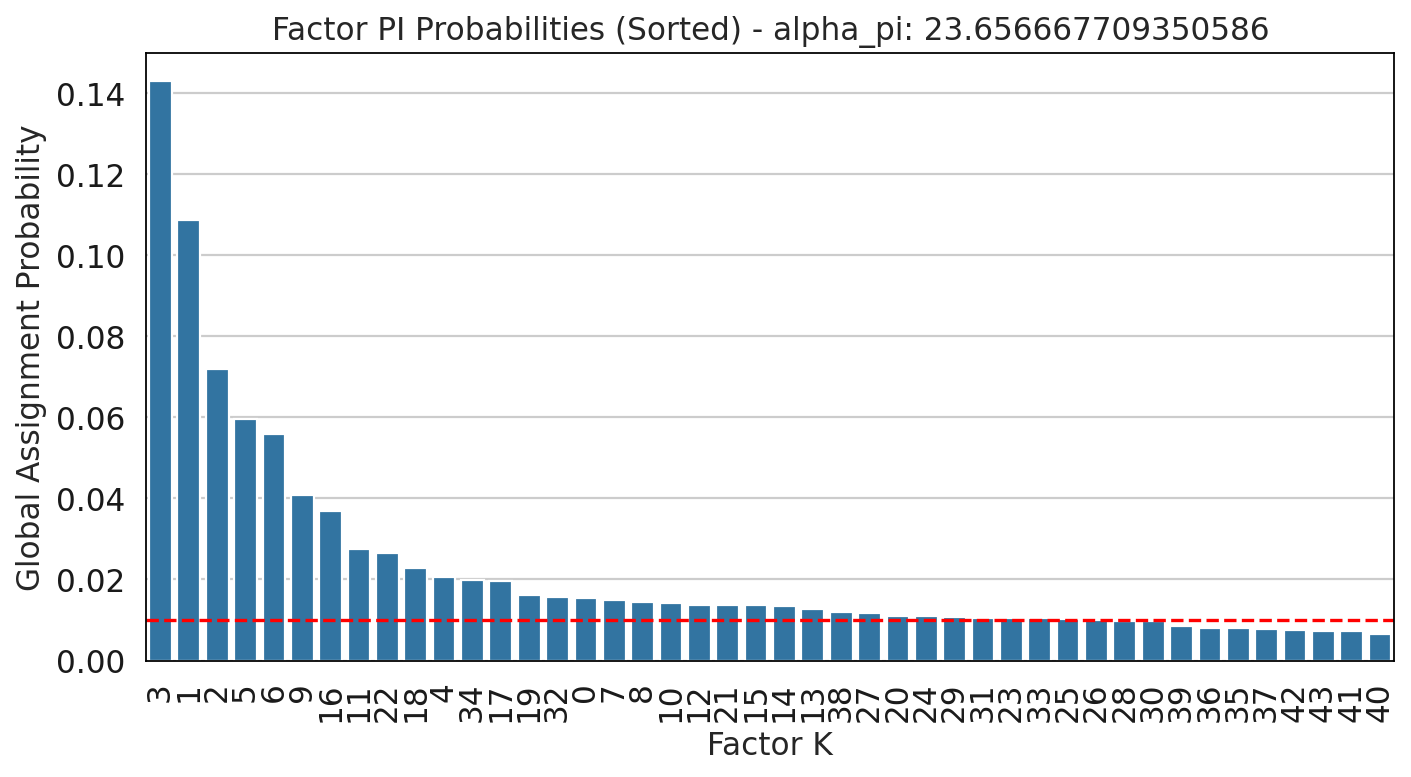

In [13]:
# Make a quick barplot of PI 
PI_df = pd.DataFrame(PI, columns=["PI"])
PI_df["Factor"] = PI_df.index
PI_df = PI_df.sort_values(by="PI", ascending=False)

print(f"Original K is {K} and reduced K is {len(PI_df)}")

plt.figure(figsize=(10, 5))
sns.barplot(x="Factor", y="PI", data=PI_df, order=PI_df["Factor"])
# Add title and include alpha_pi in title 
plt.title(f"Factor PI Probabilities (Sorted) - alpha_pi: {alpha_pi}")
plt.xlabel("Factor K")
plt.ylabel("Global Assignment Probability")
plt.axhline(0.01, color="red", linestyle="--")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors

In [14]:
K

44

In [24]:
# Add PHI to adata 
splice_adata.obsm["X_PHI"] = PHI
sc.pp.neighbors(splice_adata, use_rep="X_PHI")
sc.tl.umap(splice_adata)

In [ ]:
splice_adata.obs[splice_adata.obs["cell_type"] == ""]

In [ ]:
METADATA_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/human_metadata_combined.tsv" #note this metadata might be just Smart-seq2 cells/nuceli... (as in no 10X here)
meta = pd.read_csv(METADATA_PATH, sep="\t")
meta.head()

In [ ]:
splice_adata

In [15]:
splice_adata.obs[["dataset", "age"]].value_counts()

dataset         age
allen_brain     54     19514
                43     18518
tabula_sapiens  59     15284
allen_brain     50     11323
tabula_sapiens  61     10978
                69      4358
                38      3331
                33      1390
                42       984
                67       830
                56       623
                22       457
                74       274
                57       263
                46       171
                40       111
Name: count, dtype: int64

In [18]:
splice_adata.var[splice_adata.var["gene_name"] == "CSDE1"]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,junction_id_index,RBP_gene
9486,chr1_114718745_114719578_-,ATSE_3147,GT-AG,both,CSDE1,ENSG00000009307,3,1.0,0.0,889208,15931,0.180197,2.0,1.5,1,9486,False
9487,chr1_114718745_114720538_-,ATSE_3147,GT-AG,both,CSDE1,ENSG00000009307,3,1.0,0.0,9071,890,0.010067,2.0,1.5,1,9487,False
9488,chr1_114719742_114720538_-,ATSE_3147,GT-AG,both,CSDE1,ENSG00000009307,3,1.0,0.0,705469,13288,0.150301,2.0,1.5,1,9488,False
9489,chr1_114727087_114730257_-,ATSE_3148,GT-AG,both,CSDE1,ENSG00000009307,2,1.0,0.0,9376,1274,0.014410,2.0,1.5,1,9489,False
9490,chr1_114727090_114730257_-,ATSE_3148,GT-AG,both,CSDE1,ENSG00000009307,2,1.0,0.0,296578,8753,0.099006,2.0,1.5,1,9490,False
9491,chr1_114736855_114737470_-,ATSE_3149,GT-AG,both,CSDE1,ENSG00000009307,3,1.0,0.0,17201,896,0.010135,2.0,1.5,1,9491,False
9492,chr1_114736855_114737962_-,ATSE_3149,GT-AG,both,CSDE1,ENSG00000009307,3,1.0,0.0,182282,6353,0.071859,2.0,1.5,1,9492,False
9493,chr1_114737563_114737962_-,ATSE_3149,GT-AG,both,CSDE1,ENSG00000009307,3,1.0,0.0,17770,994,0.011243,2.0,1.5,1,9493,False
9494,chr1_114738004_114749820_-,ATSE_3146,GT-AG,both,CSDE1,ENSG00000009307,4,1.0,0.0,3746,585,0.006617,2.0,0.0,1,9494,False
9495,chr1_114738072_114739691_-,ATSE_3146,GT-AG,both,CSDE1,ENSG00000009307,4,1.0,0.0,235763,7411,0.083826,2.0,1.5,1,9495,False


In [19]:
# Check if have any CSDE1 
splice_adata

AnnData object with n_obs × n_vars = 88409 × 23942
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type_grouped', 'cell_type', 'broad_cell_type', 'cell_id_index', 'cell_id_clean', 'seqtech'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'splice_motif_score', 'junction_id_index', 'RBP_gene'
    uns: 'neighbors', 'pca_explained_variance_ratio'
    obsm: 'X_pca', 'phi_init_50_waypoints'
    varm: 'psi_init_50_waypoints'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix', 'PSI_CELLS'
    obsp: 'connectivities', 'distances'

In [20]:
# Assuming `df["cell_type"]` is your column of interest
cell_type_counts = splice_adata.obs["cell_type"].value_counts()

# Filter to show only cell types with more than 100 cells
cell_types_over_100 = cell_type_counts[cell_type_counts >= 1]

# Display all (no truncation)
with pd.option_context("display.max_rows", None):
    print(cell_types_over_100)


cell_type
Exc L2-3 LINC00507 RPL9P17                              6497
cd4-positive, alpha-beta t cell                         3000
Exc L6 THEMIS LINC00343                                 2845
cd8-positive, alpha-beta t cell                         2684
fibroblast                                              2553
macrophage                                              2468
b cell                                                  2461
Exc L4-5 RORB LINC01474                                 2248
Exc L4-5 RORB RPL31P31                                  2011
                                                        1985
neutrophil                                              1794
Oligo L4-6 OPALIN                                       1674
Exc L2-4 RORB GRIK1                                     1556
basal cell                                              1502
plasma cell                                             1445
mesenchymal stem cell                                   1441
monocyte      

In [21]:
broad_cell_type_mapping = {
    # Neurons with main subtypes preserved
    # Excitatory neurons
    "Exc L2-3 LINC00507 RPL9P17": "EXCITATORY_NEURON",
    "Exc L6 THEMIS LINC00343": "EXCITATORY_NEURON",
    "Exc L4-5 RORB LINC01474": "EXCITATORY_NEURON",
    "Exc L4-5 RORB RPL31P31": "EXCITATORY_NEURON",
    "Exc L2-4 RORB GRIK1": "EXCITATORY_NEURON",
    "Exc L4-5 RORB LCN15": "EXCITATORY_NEURON",
    "Exc L4 RORB BHLHE22": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 FAM95C": "EXCITATORY_NEURON",
    "Exc L3-4 RORB PRSS12": "EXCITATORY_NEURON",
    "Exc L6 THEMIS EGR3": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 VWA2": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 KRT17": "EXCITATORY_NEURON",
    "Exc L3-5 RORB CMAHP": "EXCITATORY_NEURON",
    "Exc L5-6 FEZF2 MYBPHL": "EXCITATORY_NEURON",
    "Exc L5-6 THEMIS GPR21": "EXCITATORY_NEURON",
    "Exc L3-4 RORB SEMA6D": "EXCITATORY_NEURON",
    "Exc L4-5 RORB HNRNPA1P46": "EXCITATORY_NEURON",
    "Exc L4 RORB CACNG5": "EXCITATORY_NEURON",
    "Exc L5 RORB SNHG7": "EXCITATORY_NEURON",
    "Exc L5-6 THEMIS IL7R": "EXCITATORY_NEURON",
    "Exc L3 LINC00507 PSRC1": "EXCITATORY_NEURON",
    "Exc L3-4 RORB FOLH1B": "EXCITATORY_NEURON",
    "Exc L3 RORB CARTPT": "EXCITATORY_NEURON",
    "Exc L5-6 THEMIS TMEM233": "EXCITATORY_NEURON",
    "Exc L5 RORB LINC01202": "EXCITATORY_NEURON",
    "Exc L3 LINC00507 CTXN3": "EXCITATORY_NEURON",
    "Exc L5-6 FEZF2 ANKRD20A1": "EXCITATORY_NEURON",
    "Exc L5-6 RORB LINC00320": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 ETV4": "EXCITATORY_NEURON",
    "Exc L4 RORB CCDC168": "EXCITATORY_NEURON",
    "Exc L4-6 RORB HPCA": "EXCITATORY_NEURON",
    "Exc L3-5 RORB HSPB3": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 CPZ": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 TBCC": "EXCITATORY_NEURON",
    "Exc L4-5 RORB ASCL1": "EXCITATORY_NEURON",
    "Exc L3-5 THEMIS UBE2F": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 SLITRK6": "EXCITATORY_NEURON",
    "Exc L3-5 RORB CD24": "EXCITATORY_NEURON",
    "Exc L5-6 FEZF2 CYP26B1": "EXCITATORY_NEURON",
    "Exc L6 THEMIS C6orf48": "EXCITATORY_NEURON",
    "Exc L3-4 RORB RPS3P6": "EXCITATORY_NEURON",
    "Exc L3-5 THEMIS ELOF1": "EXCITATORY_NEURON",
    "Exc L5-6 THEMIS OR1J1": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 TBC1D26": "EXCITATORY_NEURON",
    "Exc L4-5 RORB AIM2": "EXCITATORY_NEURON",
    "Exc L3 THEMIS PLA2G7": "EXCITATORY_NEURON",
    "Exc L5-6 THEMIS THTPA": "EXCITATORY_NEURON",
    "Exc L5-6 FEZF2 RSAD2": "EXCITATORY_NEURON",
    "Exc L5 FEZF2 MORN2": "EXCITATORY_NEURON",
    "Exc L3-5 LINC00507 SLN": "EXCITATORY_NEURON",
    "Exc L5 FEZF2 SCN7A": "EXCITATORY_NEURON",
    "Exc L6 FEZF2 P4HA3": "EXCITATORY_NEURON",
    "Exc L5 FEZF2 DYRK2": "EXCITATORY_NEURON",
    "Exc L3-5 FEZF2 DCN": "EXCITATORY_NEURON",
    "Exc L5-6 FEZF2 CABP7": "EXCITATORY_NEURON",
    "Exc L3-5 FEZF2 ONECUT1": "EXCITATORY_NEURON",
    
    # Inhibitory neurons
    "Inh L3-5 SST MAFB": "INHIBITORY_NEURON",
    "Inh L2-4 PVALB C8orf4": "INHIBITORY_NEURON",
    "Inh L1-4 LAMP5 DUSP4": "INHIBITORY_NEURON",
    "Inh L4-6 SST MTHFD2P6": "INHIBITORY_NEURON",
    "Inh L1 LAMP5 NDNF": "INHIBITORY_NEURON",
    "Inh L5 PVALB CNTNAP3P2": "INHIBITORY_NEURON",
    "Inh L1-3 VIP ZNF322P1": "INHIBITORY_NEURON",
    "Inh L1 ADARB2 ADAM33": "INHIBITORY_NEURON",
    "Inh L5-6 LAMP5 SFTA3": "INHIBITORY_NEURON",
    "Inh L3-4 PVALB HOMER3": "INHIBITORY_NEURON",
    "Inh L1 SST CXCL14": "INHIBITORY_NEURON",
    "Inh L5-6 PVALB STON2": "INHIBITORY_NEURON",
    "Inh L1-6 LAMP5 CA13": "INHIBITORY_NEURON",
    "Inh L2-5 VIP TOX2": "INHIBITORY_NEURON",
    "Inh L2-6 VIP VIP": "INHIBITORY_NEURON",
    "Inh L1-3 PVALB WFDC2": "INHIBITORY_NEURON",
    "Inh L1 PAX6 CA4": "INHIBITORY_NEURON",
    "Inh L5-6 SST ISOC1": "INHIBITORY_NEURON",
    "Inh L1-3 VIP GGH": "INHIBITORY_NEURON",
    "Inh L5-6 PVALB FAM150B": "INHIBITORY_NEURON",
    "Inh L1-5 VIP KCNJ2": "INHIBITORY_NEURON",
    "Inh L1-6 VIP RGS16": "INHIBITORY_NEURON",
    "Inh L3 VIP CBLN1": "INHIBITORY_NEURON",
    "Inh L2-4 SST AHR": "INHIBITORY_NEURON",
    "Inh L1 VIP PRSS8": "INHIBITORY_NEURON",
    "Inh L1-3 VIP SSTR1": "INHIBITORY_NEURON",
    "Inh L1-4 VIP CHRNA2": "INHIBITORY_NEURON",
    "Inh L2-4 VIP DSEL": "INHIBITORY_NEURON",
    "Inh L1-3 VIP ACHE": "INHIBITORY_NEURON",
    "Inh L1-6 PVALB SCUBE3": "INHIBITORY_NEURON",
    "Inh L1 VIP PCDH20": "INHIBITORY_NEURON",
    "Inh L1-2 VIP RPL41P3": "INHIBITORY_NEURON",
    "Inh L3-6 VIP KCTD13": "INHIBITORY_NEURON",
    "Inh L2-4 VIP LGI2": "INHIBITORY_NEURON",
    "Inh L4-5 PVALB TRIM67": "INHIBITORY_NEURON",
    "Inh L5-6 SST TH": "INHIBITORY_NEURON",
    "Inh L6 LHX6 GLP1R": "INHIBITORY_NEURON",
    "Inh L5-6 SST KLHL14": "INHIBITORY_NEURON",
    "Inh L6 LAMP5 C1QL2": "INHIBITORY_NEURON",
    "Inh L3-6 PVALB MFI2": "INHIBITORY_NEURON",
    "Inh L1-6 VIP PENK": "INHIBITORY_NEURON",
    "Inh L1 LAMP5 GGT8P": "INHIBITORY_NEURON",
    "Inh L1-3 PAX6 NABP1": "INHIBITORY_NEURON",
    "Inh L1-6 VIP RCN1": "INHIBITORY_NEURON",
    "Inh L1 PAX6 GRIP2": "INHIBITORY_NEURON",
    "Inh L1 VIP TNFAIP8L3": "INHIBITORY_NEURON",
    "Inh L6 SST NPY": "INHIBITORY_NEURON",
    "Inh L1-2 VIP PPAPDC1A": "INHIBITORY_NEURON",
    "Inh L1-2 PAX6 SCGN": "INHIBITORY_NEURON",
    "Inh L1-2 PVALB TAC1": "INHIBITORY_NEURON",
    "Inh L1-3 VIP CCDC184": "INHIBITORY_NEURON",
    "Inh L1 VIP SOX11": "INHIBITORY_NEURON",
    "Inh L1 ADARB2 DISP2": "INHIBITORY_NEURON",
    "Inh L6 LAMP5 ANKRD20A11P": "INHIBITORY_NEURON",
    
    # Other neurons (sensory, etc.)
    "retinal bipolar neuron": "OTHER_NEURON",
    "eye photoreceptor cell": "SENSORY_NEURON",
    "taste receptor cell": "SENSORY_NEURON",
    
    # All glial cells in one category
    "Oligo L4-6 OPALIN": "GLIAL_CELL",
    "OPC L1-6 MYT1": "GLIAL_CELL",
    "Oligo L4-6 MOBP COL18A1": "GLIAL_CELL",
    "Astro L1-6 FGFR3 ETNPPL": "GLIAL_CELL",
    "Astro L1 FGFR3 MT1G": "GLIAL_CELL",
    "Astro L1 FGFR3 FOS": "GLIAL_CELL",
    "Micro L1-6 C1QC": "GLIAL_CELL",
    "microglial cell": "GLIAL_CELL",
    "enteroglial cell": "GLIAL_CELL",
    "mueller cell": "GLIAL_CELL",
    "schwann cell": "GLIAL_CELL",
    "radial glial cell": "GLIAL_CELL",
    
    # All endothelial cells from any tissue
    "Endo L2-5 CLDN5": "ENDOTHELIAL_CELL",
    "endothelial cell": "ENDOTHELIAL_CELL",
    "capillary endothelial cell": "ENDOTHELIAL_CELL",
    "endothelial cell of vascular tree": "ENDOTHELIAL_CELL",
    "vein endothelial cell": "ENDOTHELIAL_CELL",
    "cardiac endothelial cell": "ENDOTHELIAL_CELL",
    "endothelial cell of artery": "ENDOTHELIAL_CELL",
    "endothelial cell of lymphatic vessel": "ENDOTHELIAL_CELL",
    "colon endothelial cell": "ENDOTHELIAL_CELL",
    "retinal blood vessel endothelial cell": "ENDOTHELIAL_CELL",
    "endothelial cell of arteriole": "ENDOTHELIAL_CELL",
    "endothelial cell of venule": "ENDOTHELIAL_CELL",
    
    # All T cells and related
    "cd4-positive, alpha-beta t cell": "T_CELL",
    "cd8-positive, alpha-beta t cell": "T_CELL",
    "naive thymus-derived cd4-positive, alpha-beta t cell": "T_CELL",
    "mature nk t cell": "T_CELL",
    "t cell": "T_CELL",
    "cd4-positive, alpha-beta thymocyte": "T_CELL",
    "cd8-positive, alpha-beta thymocyte": "T_CELL",
    "regulatory t cell": "T_CELL",
    "activated cd4-positive, alpha-beta t cell": "T_CELL",
    "thymocyte": "T_CELL",
    "gamma-delta t cell": "T_CELL",
    "t follicular helper cell": "T_CELL",
    "activated cd8-positive, alpha-beta t cell": "T_CELL",
    
    # All B cells
    "b cell": "B_CELL",
    "plasma cell": "B_CELL",
    
    # Other immune cells
    "macrophage": "MYELOID_CELL",
    "neutrophil": "MYELOID_CELL",
    "monocyte": "MYELOID_CELL",
    "classical monocyte": "MYELOID_CELL",
    "myeloid dendritic cell": "MYELOID_CELL",
    "granulocyte": "MYELOID_CELL",
    "myeloid cell": "MYELOID_CELL",
    "non-classical monocyte": "MYELOID_CELL",
    "common myeloid progenitor": "MYELOID_CELL",
    "intermediate monocyte": "MYELOID_CELL",
    "colon macrophage": "MYELOID_CELL",
    "tissue-resident macrophage": "MYELOID_CELL",
    "langerhans cell": "MYELOID_CELL",
    "plasmacytoid dendritic cell": "MYELOID_CELL",
    "basophil": "MYELOID_CELL",
    
    # Lymphoid cells (not T or B)
    "natural killer cell": "LYMPHOID_CELL",
    "innate lymphoid cell": "LYMPHOID_CELL",
    
    # Other blood cells
    "erythroid progenitor cell": "ERYTHROID_CELL",
    "erythrocyte": "ERYTHROID_CELL",
    "platelet": "PLATELET",
    "erythroid lineage cell": "ERYTHROID_CELL",
    "leukocyte": "LEUKOCYTE",
    "hematopoietic stem cell": "HEMATOPOIETIC_STEM_CELL",
    "mast cell": "MAST_CELL",
    
    # All stromal cells (fibroblasts, etc.)
    "fibroblast": "STROMAL_CELL",
    "adventitial cell": "STROMAL_CELL",
    "myofibroblast cell": "STROMAL_CELL",
    "fibroblast of breast": "STROMAL_CELL",
    "fibroblast of cardiac tissue": "STROMAL_CELL",
    "alveolar type 2 fibroblast cell": "STROMAL_CELL",
    "tendon cell": "STROMAL_CELL",
    "stromal cell": "STROMAL_CELL",
    "hepatic stellate cell": "STROMAL_CELL",
    "pericyte": "STROMAL_CELL",
    "Peri L1-6 MUSTN1": "STROMAL_CELL",
    "mural cell": "STROMAL_CELL",
    "keratocyte": "STROMAL_CELL",
    "mesothelial cell": "STROMAL_CELL",
    "VLMC L1-3 CYP1B1": "STROMAL_CELL",
    
    # All stem cells and progenitors
    "mesenchymal stem cell": "STEM_CELL",
    "skeletal muscle satellite stem cell": "STEM_CELL",
    "intestinal crypt stem cell of small intestine": "STEM_CELL",
    "intestinal crypt stem cell of colon": "STEM_CELL",
    "mesenchymal stem cell of adipose tissue": "STEM_CELL",
    "transit amplifying cell of small intestine": "STEM_CELL",
    "epithelial fate stem cell": "STEM_CELL",
    "mesenchymal cell": "STEM_CELL",
    
    # All epithelial cells (one category)
    "basal cell": "EPITHELIAL_CELL",
    "enterocyte of epithelium of large intestine": "EPITHELIAL_CELL",
    "enterocyte of epithelium proper of small intestine": "EPITHELIAL_CELL",
    "type ii pneumocyte": "EPITHELIAL_CELL",
    "bladder urothelial cell": "EPITHELIAL_CELL",
    "luminal cell of prostate epithelium": "EPITHELIAL_CELL",
    "paneth cell of epithelium of small intestine": "EPITHELIAL_CELL",
    "paneth cell of colon": "EPITHELIAL_CELL",
    "kidney epithelial cell": "EPITHELIAL_CELL",
    "lung ciliated cell": "EPITHELIAL_CELL",
    "small intestine goblet cell": "EPITHELIAL_CELL",
    "epithelial cell of uterus": "EPITHELIAL_CELL",
    "tracheal goblet cell": "EPITHELIAL_CELL",
    "stratified squamous epithelial cell": "EPITHELIAL_CELL",
    "type i pneumocyte": "EPITHELIAL_CELL",
    "respiratory goblet cell": "EPITHELIAL_CELL",
    "duct epithelial cell": "EPITHELIAL_CELL",
    "sebum secreting cell": "EPITHELIAL_CELL",
    "basal cell of prostate epithelium": "EPITHELIAL_CELL",
    "intrahepatic cholangiocyte": "EPITHELIAL_CELL",
    "acinar cell": "EPITHELIAL_CELL",
    "tuft cell of colon": "EPITHELIAL_CELL",
    "intestinal tuft cell": "EPITHELIAL_CELL",
    "ciliated columnar cell of tracheobronchial tree": "EPITHELIAL_CELL",
    "luminal epithelial cell of mammary gland": "EPITHELIAL_CELL",
    "club cell": "EPITHELIAL_CELL",
    "conjunctival epithelial cell": "EPITHELIAL_CELL",
    "enteroendocrine cell of small intestine": "EPITHELIAL_CELL",
    "corneal epithelial cell": "EPITHELIAL_CELL",
    "ionocyte": "EPITHELIAL_CELL",
    "best4+ intestinal epithelial cell, human": "EPITHELIAL_CELL",
    "serous cell of epithelium of bronchus": "EPITHELIAL_CELL",
    "ciliated epithelial cell": "EPITHELIAL_CELL",
    "retinal pigment epithelial cell": "EPITHELIAL_CELL",
    "epithelial cell": "EPITHELIAL_CELL",
    "enterocyte of epithelium proper of ileum": "EPITHELIAL_CELL",
    "pulmonary ionocyte": "EPITHELIAL_CELL",
    "large intestine goblet cell": "EPITHELIAL_CELL",
    "enterocyte of epithelium proper of duodenum": "EPITHELIAL_CELL",
    "enterochromaffin-like cell": "EPITHELIAL_CELL",
    "mucus secreting cell": "EPITHELIAL_CELL",
    "type l enteroendocrine cell": "EPITHELIAL_CELL",
    "medullary thymic epithelial cell": "EPITHELIAL_CELL",
    "acinar cell of salivary gland": "EPITHELIAL_CELL",
    "salivary gland cell": "EPITHELIAL_CELL",
    "myoepithelial cell": "EPITHELIAL_CELL",
    
    # All muscle cells
    "smooth muscle cell": "MUSCLE_CELL",
    "vascular associated smooth muscle cell": "MUSCLE_CELL",
    "bronchial smooth muscle cell": "MUSCLE_CELL",
    "fast muscle cell": "MUSCLE_CELL",
    "slow muscle cell": "MUSCLE_CELL",
    "regular atrial cardiac myocyte": "MUSCLE_CELL",
    "tongue muscle cell": "MUSCLE_CELL",
    "ventricular cardiac muscle cell": "MUSCLE_CELL",
    
    # Specialized cells
    "fat cell": "ADIPOCYTE",
    "melanocyte": "MELANOCYTE",
    "hepatocyte": "HEPATOCYTE",
    
    # Empty or unlabeled
    "": "UNLABELED"
}

In [22]:
# First, ensure you have the mapping dictionary (broad_cell_type_mapping from above)

# Function to map cell types to broader categories, with a fallback
def map_to_broad_type(cell_type):
    # If the cell type is in our mapping dictionary, use that mapping
    if cell_type in broad_cell_type_mapping:
        return broad_cell_type_mapping[cell_type]
    
    # For cell types not explicitly in the dictionary, try to infer broader category
    if 'Exc' in cell_type:
        return 'EXCITATORY_NEURON'
    elif 'Inh' in cell_type:
        return 'INHIBITORY_NEURON'
    elif 'Oligo' in cell_type:
        return 'GLIAL_CELL'
    elif 'Astro' in cell_type:
        return 'GLIAL_CELL'
    elif 'Micro' in cell_type:
        return 'GLIAL_CELL'
    elif 'Endo' in cell_type:
        return 'ENDOTHELIAL_CELL'
    elif 'Peri' in cell_type:
        return 'STROMAL_CELL'
    
    # Default case
    return 'OTHER'

# Apply the mapping function to create the new column
splice_adata.obs['broad_cell_type'] = splice_adata.obs['cell_type'].apply(map_to_broad_type)
splice_adata.obs['broad_cell_type'] = splice_adata.obs['broad_cell_type'].astype('category')
# Print value counts to verify the results
print(splice_adata.obs['broad_cell_type'].value_counts())

broad_cell_type
EXCITATORY_NEURON          31183
INHIBITORY_NEURON          11438
MYELOID_CELL                7312
T_CELL                      6952
EPITHELIAL_CELL             6889
GLIAL_CELL                  4780
STROMAL_CELL                4102
ENDOTHELIAL_CELL            3939
B_CELL                      3906
STEM_CELL                   2149
UNLABELED                   1985
LYMPHOID_CELL               1536
MUSCLE_CELL                  808
MAST_CELL                    605
HEMATOPOIETIC_STEM_CELL      271
ERYTHROID_CELL               210
LEUKOCYTE                    166
PLATELET                      47
SENSORY_NEURON                43
ADIPOCYTE                     39
MELANOCYTE                    29
HEPATOCYTE                    14
OTHER_NEURON                   6
Name: count, dtype: int64


### LeafletFA vs aging regression 

In [25]:
splice_adata.obs["age_group"] = splice_adata.obs["age"].astype(int)

# Define the target variable
y = splice_adata.obs["age_group"]
X = splice_adata.obsm["X_PHI"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

def plot_celltype_vs_seqtech_umap(adata, target_cell_type, cell_type_col="broad_cell_type", seqtech_col="seqtech"):
    # UMAP coordinates
    umap = adata.obsm["X_umap"]
    
    # Boolean mask for the target cell type
    is_target = adata.obs[cell_type_col] == target_cell_type

    # Plot settings
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # --- Panel A: Highlight cell type ---
    axs[0].scatter(umap[~is_target, 0], umap[~is_target, 1], color="lightgrey", s=2, alpha=0.1, label="Other")
    axs[0].scatter(umap[is_target, 0], umap[is_target, 1], color="crimson", s=3, alpha=0.5, label=target_cell_type)
    axs[0].set_title(f"UMAP: {target_cell_type} highlighted")
    axs[0].axis("off")

    # --- Panel B: Color same cells by seqtech ---
    unique_techs = adata.obs[seqtech_col].unique()
    palette = sns.color_palette("tab10", len(unique_techs))
    tech_colors = dict(zip(unique_techs, palette))
    tech_values = adata.obs[seqtech_col]

    for tech in unique_techs:
        tech_mask = tech_values == tech
        axs[1].scatter(
            umap[tech_mask, 0],
            umap[tech_mask, 1],
            s=2,
            alpha=0.5,
            label=tech,
            color=tech_colors[tech]
        )

    axs[1].set_title("UMAP colored by seqtech")
    axs[1].axis("off")
    axs[1].legend(markerscale=2, fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

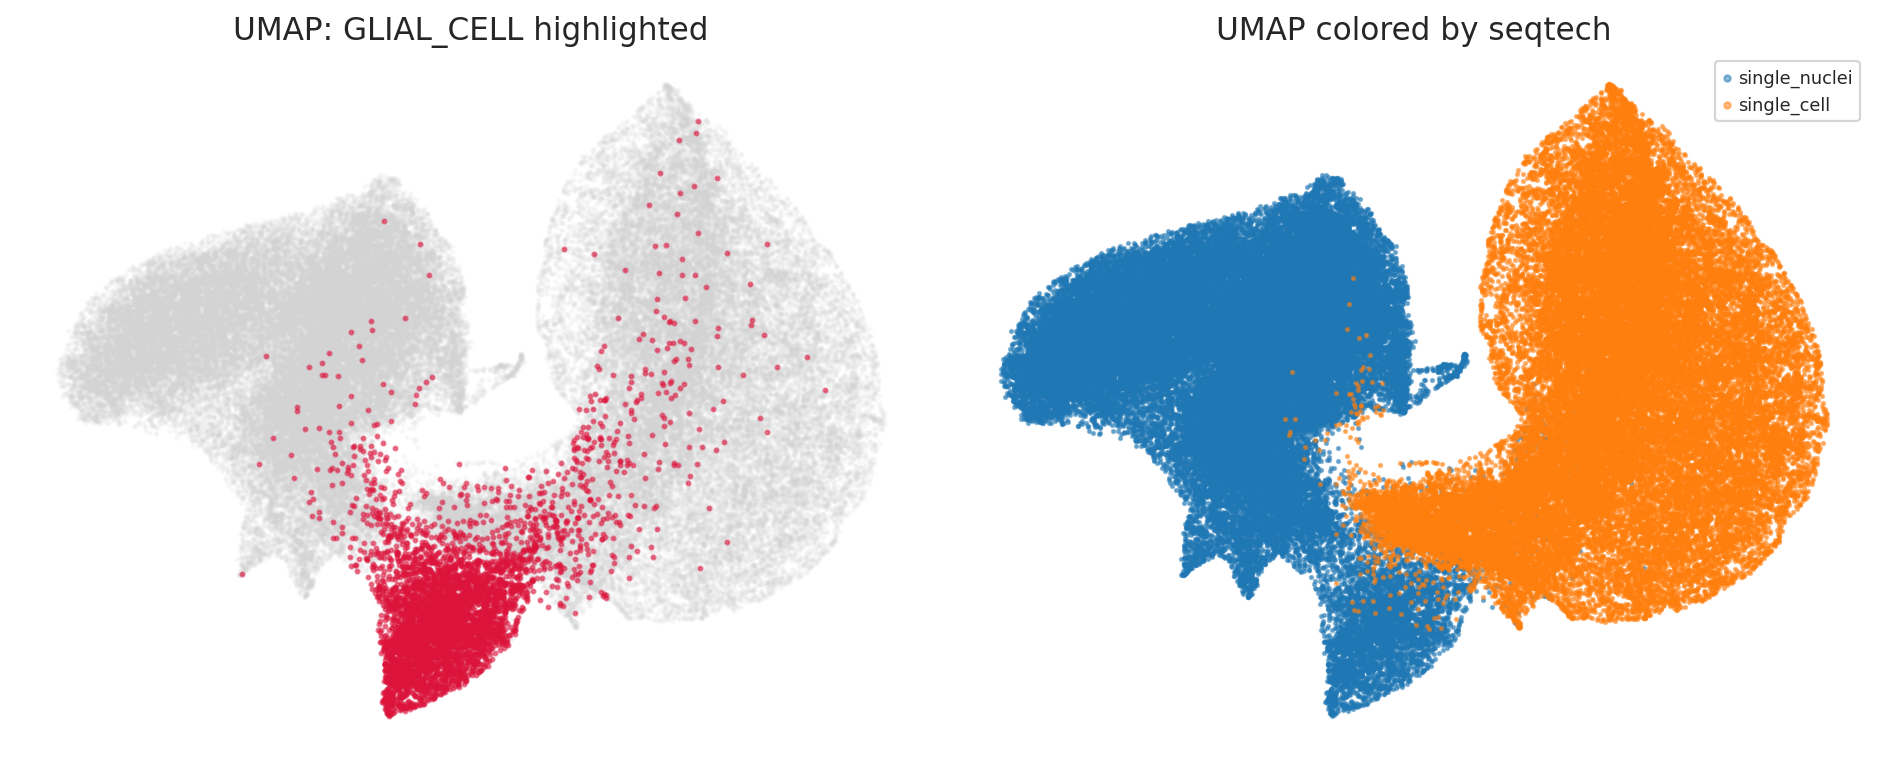

In [27]:
plot_celltype_vs_seqtech_umap(splice_adata, target_cell_type="GLIAL_CELL")

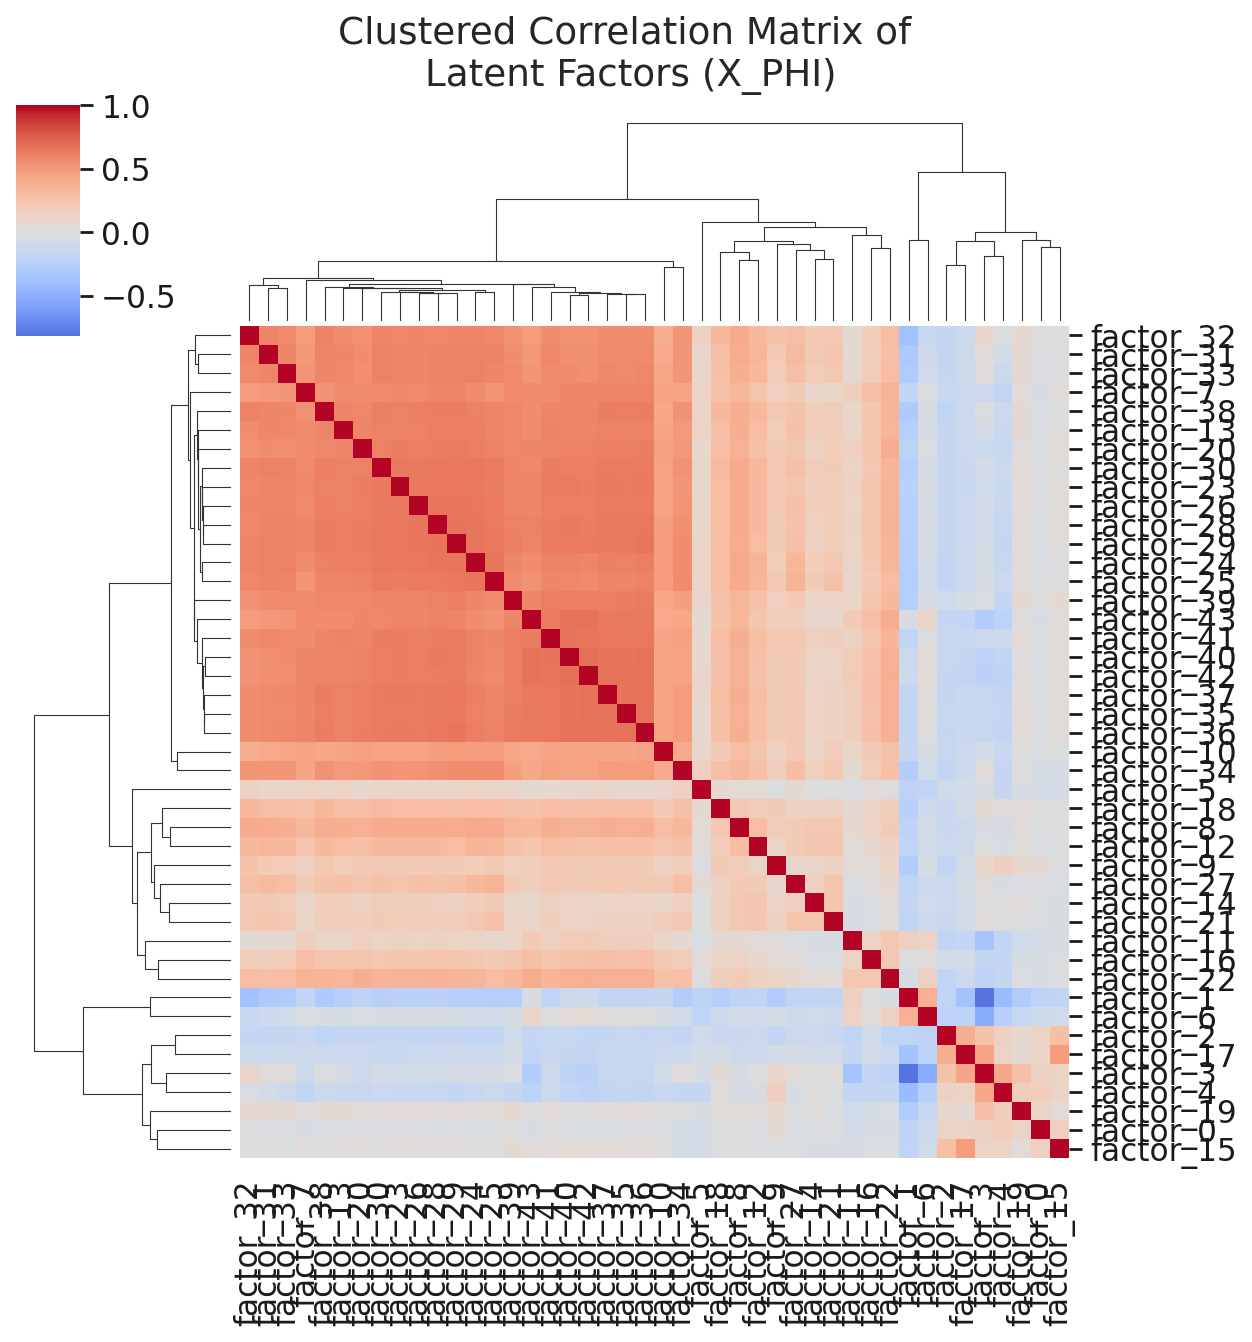

In [28]:
# Compute correlation matrix
corr_matrix = np.corrcoef(X_train.T)  # K × K

# Generate factor labels
factor_labels = [f"factor_{i}" for i in range(X_train.shape[1])]

sns.clustermap(corr_matrix, cmap="coolwarm", center=0, xticklabels=factor_labels, yticklabels=factor_labels, figsize=(8, 8))

# Add title
plt.suptitle("Clustered Correlation Matrix of \nLatent Factors (X_PHI)", y=1.05)
plt.show()

100%|██████████| 500/500 [01:31<00:00,  5.49it/s]


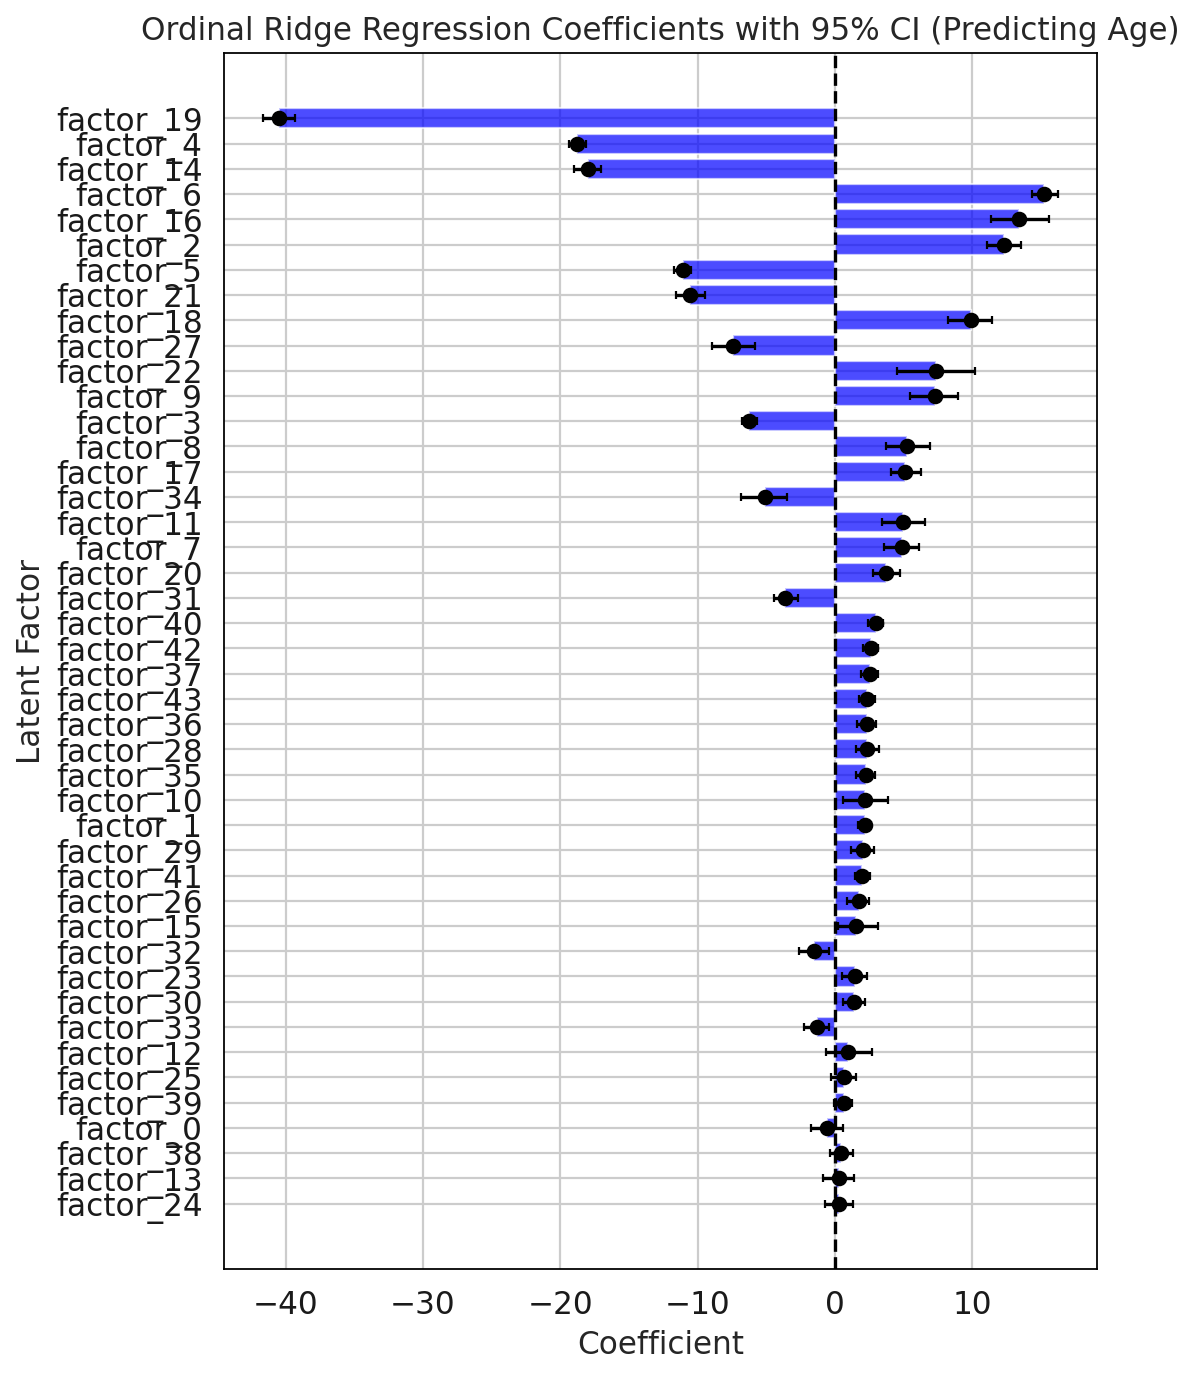

In [29]:
# Train the ordinal regression model
ordinal_model = OrdinalRidge(alpha=10.0)
ordinal_model.fit(X_train, y_train)
ordinal_coeffs = ordinal_model.coef_

# Bootstrapped Confidence Intervals
n_bootstraps = 500
bootstrap_coefs = np.zeros((n_bootstraps, X_train.shape[1]))

for i in tqdm(range(n_bootstraps)):
    X_resampled, y_resampled = resample(X_train, y_train, random_state=i)
    model = OrdinalRidge(alpha=10.0)
    model.fit(X_resampled, y_resampled)
    bootstrap_coefs[i, :] = model.coef_

# Compute 95% confidence intervals
ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)

# Factor names
factor_labels = [f"factor_{i}" for i in range(len(ordinal_coeffs))]

# Sorting factors by absolute importance (optional)
sorted_indices = np.argsort(np.abs(ordinal_coeffs))[::-1]
ordinal_coeffs = ordinal_coeffs[sorted_indices]
ci_lower = ci_lower[sorted_indices]
ci_upper = ci_upper[sorted_indices]
factor_labels = [factor_labels[i] for i in sorted_indices]

# Plot with vertical layout
plt.figure(figsize=(7, 10))
plt.barh(factor_labels, ordinal_coeffs, color="blue", alpha=0.7)
plt.errorbar(ordinal_coeffs, factor_labels, 
             xerr=[ordinal_coeffs - ci_lower, ci_upper - ordinal_coeffs], 
             fmt='o', color='black', capsize=2)

plt.axvline(0, color="black", linestyle="dashed")  # Dashed line at 0
plt.xlabel("Coefficient")
plt.ylabel("Latent Factor")
plt.title("Ordinal Ridge Regression Coefficients with 95% CI (Predicting Age)")
plt.gca().invert_yaxis()  # Invert so most important factor is at the top
plt.show()

In [30]:
splice_adata.obs["age"].unique()

array([54, 50, 43, 33, 42, 74, 22, 59, 46, 61, 57, 38, 40, 67, 69, 56])

In [31]:
# confirm that all rows sum to 1 in PHI 
assert np.allclose(np.sum(PHI, axis=1), 1.0)

### Train multiclass model to predict cell type 

In [32]:
splice_adata.obs[splice_adata.obs["cell_type_grouped"] == ""]

,cell_id,donor,sex,age,dataset,tissue,cell_type_grouped,cell_type,broad_cell_type,cell_id_index,cell_id_clean,seqtech,age_group
47,F1S4_160106_008_D01,H200.1030,M,54,allen_brain,MTG,,,UNLABELED,47,F1S4_160106_008_D01,single_nuclei,54
115,F1S4_160106_046_E01,H200.1030,M,54,allen_brain,MTG,,,UNLABELED,115,F1S4_160106_046_E01,single_nuclei,54
122,F1S4_160106_047_F01,H200.1030,M,54,allen_brain,MTG,,,UNLABELED,122,F1S4_160106_047_F01,single_nuclei,54
131,F1S4_160106_051_E01,H200.1030,M,54,allen_brain,MTG,,,UNLABELED,131,F1S4_160106_051_E01,single_nuclei,54
183,F1S4_160106_061_B01,H200.1030,M,54,allen_brain,MTG,,,UNLABELED,183,F1S4_160106_061_B01,single_nuclei,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49128,F2S4_190227_070_B01,H200.1025,M,50,allen_brain,A1C,,,UNLABELED,49128,F2S4_190227_070_B01,single_nuclei,50
49150,F2S4_190227_073_B01,H200.1025,M,50,allen_brain,A1C,,,UNLABELED,49150,F2S4_190227_073_B01,single_nuclei,50
49155,F2S4_190227_073_G01,H200.1025,M,50,allen_brain,A1C,,,UNLABELED,49155,F2S4_190227_073_G01,single_nuclei,50
49211,F2S4_190227_081_F01,H200.1025,M,50,allen_brain,A1C,,,UNLABELED,49211,F2S4_190227_081_F01,single_nuclei,50


In [ ]:
# cell_type_accuracy, model, encoder, coef_df = logistic_regression_feature_prediction_simple(splice_adata, "cell_type_grouped")
# plot_clustermap(coef_df, highlighted_factors=["factor_0", "factor_1", "factor_10", "factor_18"], cmap="seismic", figsize=(10, 10), col_cluster=True, center=0)

In [ ]:
# train the model to predict tissue via factor activity
tissue_accuracy, model, encoder, coef_df_tissue_simple = logistic_regression_feature_prediction_simple(splice_adata, "broad_cell_type")
plot_clustermap(coef_df_tissue_simple, highlighted_factors=["factor_19", "factor_4", "factor_6", "factor_16"], cmap="seismic", figsize=(12, 10), center=0)

In [ ]:
# train the model to predict tissue via factor activity
tissue_accuracy, model, encoder, coef_df_tissue_simple = logistic_regression_feature_prediction_simple(splice_adata, "tissue")
plot_clustermap(coef_df_tissue_simple, highlighted_factors=["factor_19", "factor_4", "factor_6", "factor_16"], cmap="seismic", figsize=(10, 10), center=0)

In [ ]:
# Summarize factor activities per cell type 
# Factor general activitiies of each factor 

In [ ]:
PHI

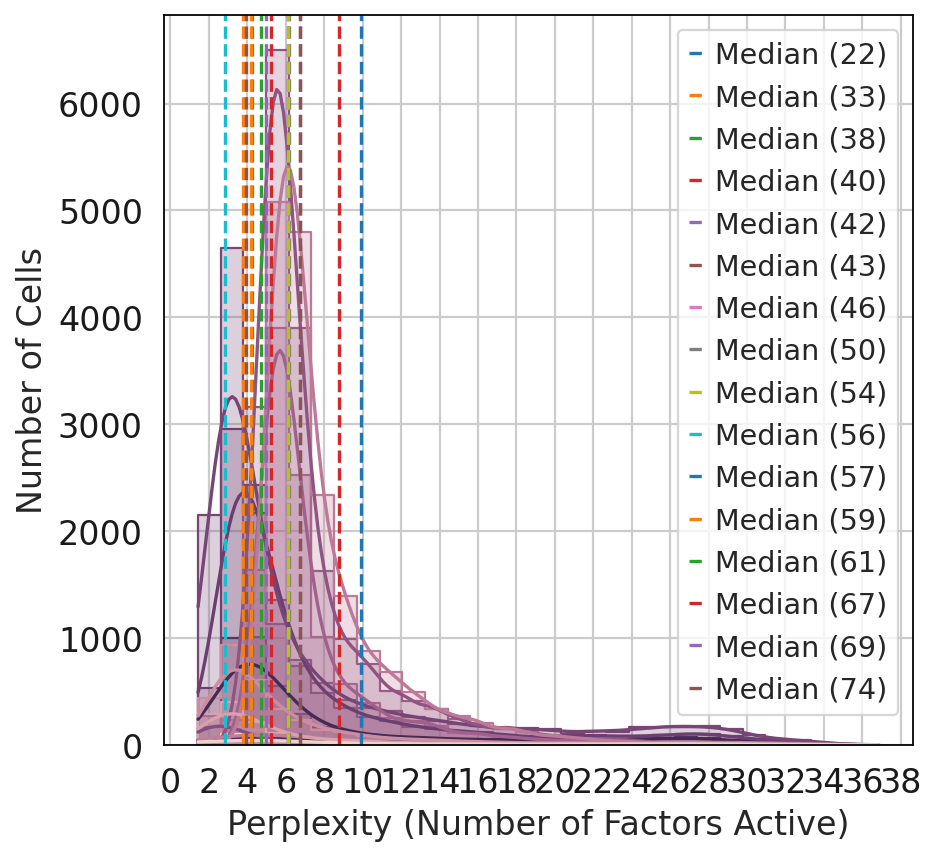

In [33]:
# Calculate entropy for each cell, ensuring numerical stability (avoid log(0))
PHI_safe = np.clip(PHI, 1e-10, 1)  # Prevent log(0) errors
entropy = -np.sum(PHI_safe * np.log(PHI_safe), axis=1)

# Calculate perplexity for each cell
perplexity = np.exp(entropy)

# Store results in `adata.obs`
splice_adata.obs["perplexity"] = perplexity
splice_adata.obs["entropy"] = entropy

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=splice_adata.obs, x="perplexity", hue="age", bins=30, kde=True, element="step")

# Get median perplexity per age group
median_perplexity = splice_adata.obs.groupby("age")["perplexity"].median()

# Assign distinct colors from the KDE curves to the median lines
palette = sns.color_palette("tab10", n_colors=len(median_perplexity))  # Use same color set as Seaborn
color_dict = dict(zip(median_perplexity.index, palette))  # Map age group to color

# Add median lines with matching colors
for age_group, median in median_perplexity.items():
    plt.axvline(median, color=color_dict[age_group], linestyle="--", linewidth=1.5, label=f"Median ({age_group})")

# Set x-axis ticks to 0, 2, 4, ...
plt.xticks(np.arange(0, max(perplexity) + 2, 2))

# Labels and title
plt.xlabel("Perplexity (Number of Factors Active)", fontsize=15)
plt.ylabel("Number of Cells", fontsize=15)

# Increase font size of xaxis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Ensure legend appears
plt.legend()

# Display the plot
plt.show()

In [36]:
# get csde1 atses and model their junction usage ratios with aging 
splice_adata.obs.broad_cell_type.value_counts()

broad_cell_type
EXCITATORY_NEURON          31183
INHIBITORY_NEURON          11438
MYELOID_CELL                7312
T_CELL                      6952
EPITHELIAL_CELL             6889
GLIAL_CELL                  4780
STROMAL_CELL                4102
ENDOTHELIAL_CELL            3939
B_CELL                      3906
STEM_CELL                   2149
UNLABELED                   1985
LYMPHOID_CELL               1536
MUSCLE_CELL                  808
MAST_CELL                    605
HEMATOPOIETIC_STEM_CELL      271
ERYTHROID_CELL               210
LEUKOCYTE                    166
PLATELET                      47
SENSORY_NEURON                43
ADIPOCYTE                     39
MELANOCYTE                    29
HEPATOCYTE                    14
OTHER_NEURON                   6
Name: count, dtype: int64

In [37]:
glia = splice_adata[splice_adata.obs['broad_cell_type'] == 'GLIAL_CELL'].copy()
glia

AnnData object with n_obs × n_vars = 4780 × 23942
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type_grouped', 'cell_type', 'broad_cell_type', 'cell_id_index', 'cell_id_clean', 'seqtech', 'age_group', 'perplexity', 'entropy'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'splice_motif_score', 'junction_id_index', 'RBP_gene'
    uns: 'neighbors', 'pca_explained_variance_ratio', 'umap'
    obsm: 'X_pca', 'phi_init_50_waypoints', 'X_PHI', 'X_umap'
    varm: 'psi_init_50_waypoints'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix', 'PSI_CELLS'
    obsp: 'connectivities', 'distances'

In [47]:
psi_long

,age,cell_id,junction_id,psi,event_id
0,54,F1S4_160106_003_A01,9486,0.731925,ATSE_3147
1,54,F1S4_160106_005_A01,9486,0.781538,ATSE_3147
2,54,F1S4_160106_007_A01,9486,0.737819,ATSE_3147
3,54,F1S4_160106_008_A01,9486,0.857271,ATSE_3147
4,54,F1S4_160106_037_A01,9486,0.737159,ATSE_3147
...,...,...,...,...,...
57355,40,TSP5_TSP5_smartseq2_B112804_B104881_Eye_whole....,9497,0.335989,ATSE_3146
57356,40,TSP5_TSP5_smartseq2_B112809_B104877_Eye_whole....,9497,0.328966,ATSE_3146
57357,40,TSP5_TSP5_smartseq2_B112809_B104877_Eye_whole....,9497,0.361287,ATSE_3146
57358,40,TSP5_TSP5_smartseq2_B112809_B104877_Eye_whole....,9497,0.339951,ATSE_3146


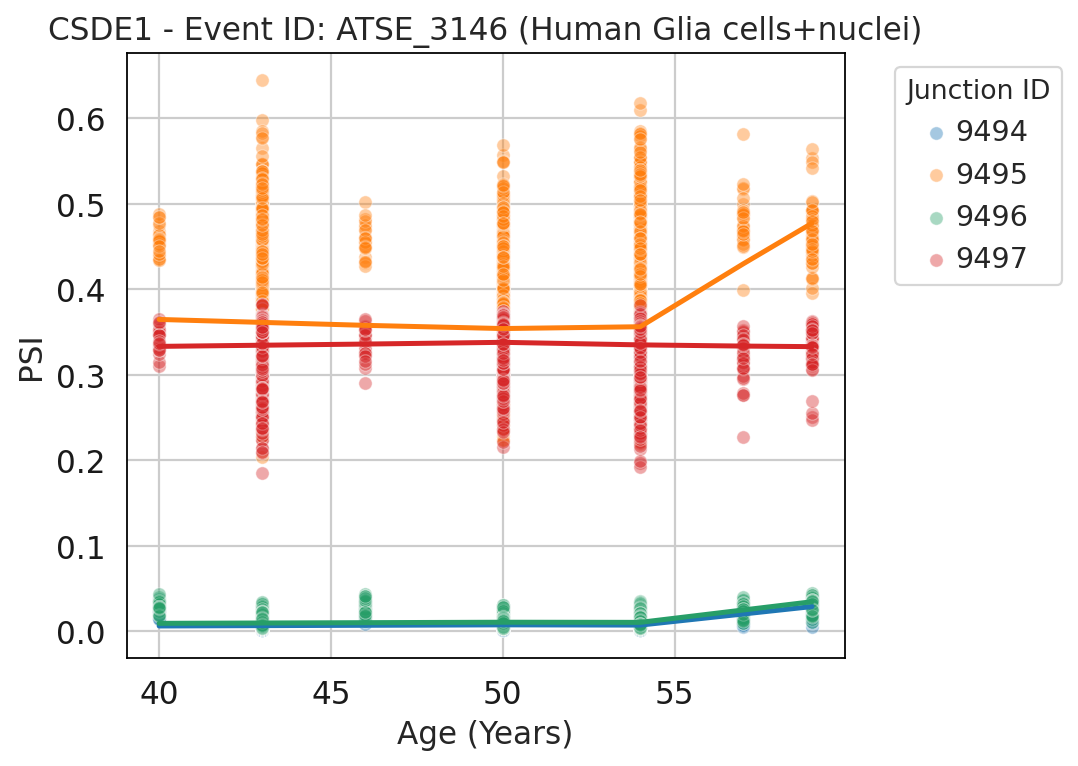

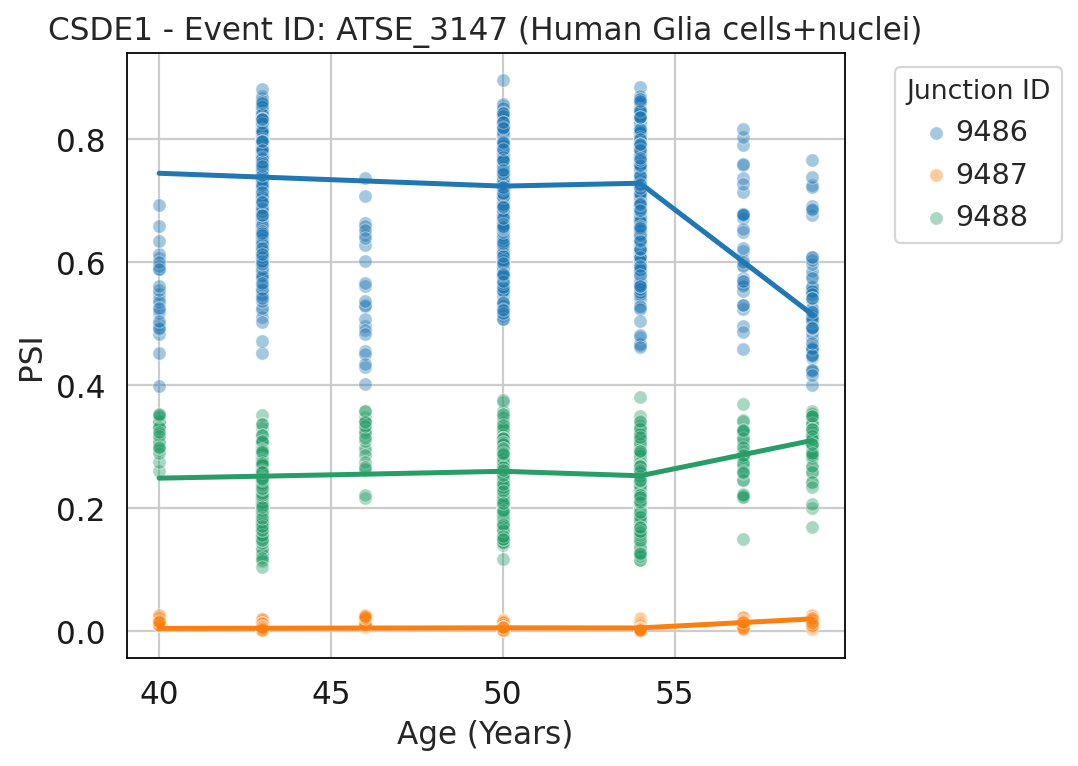

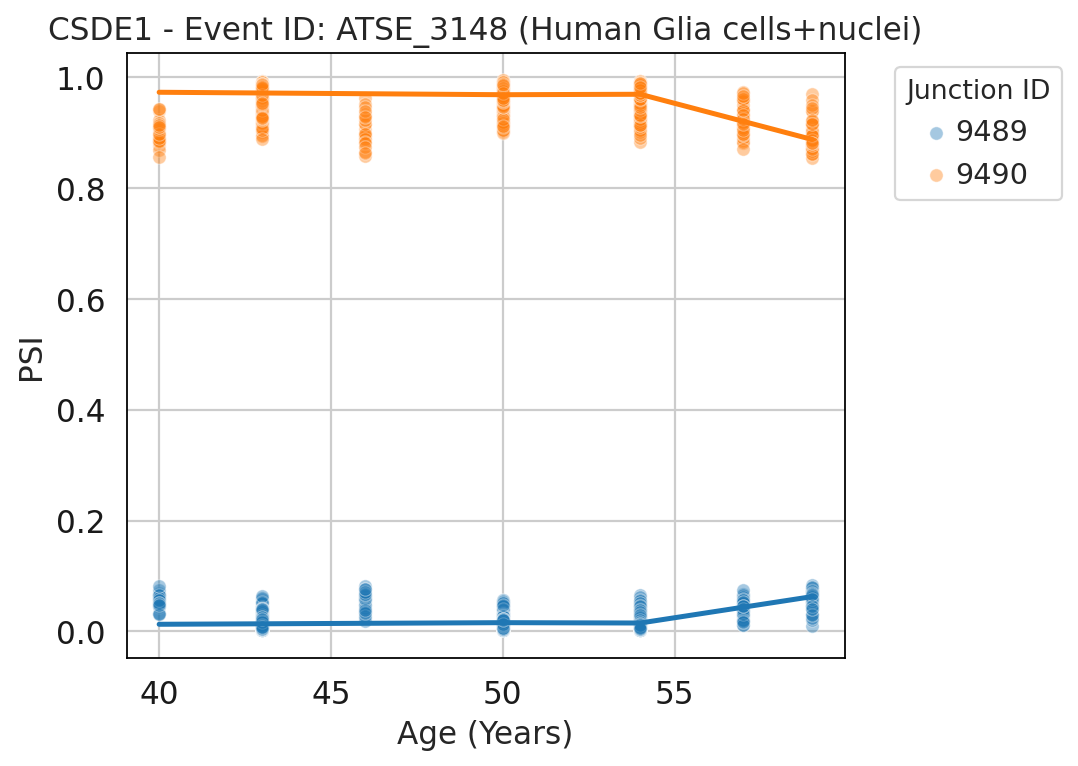

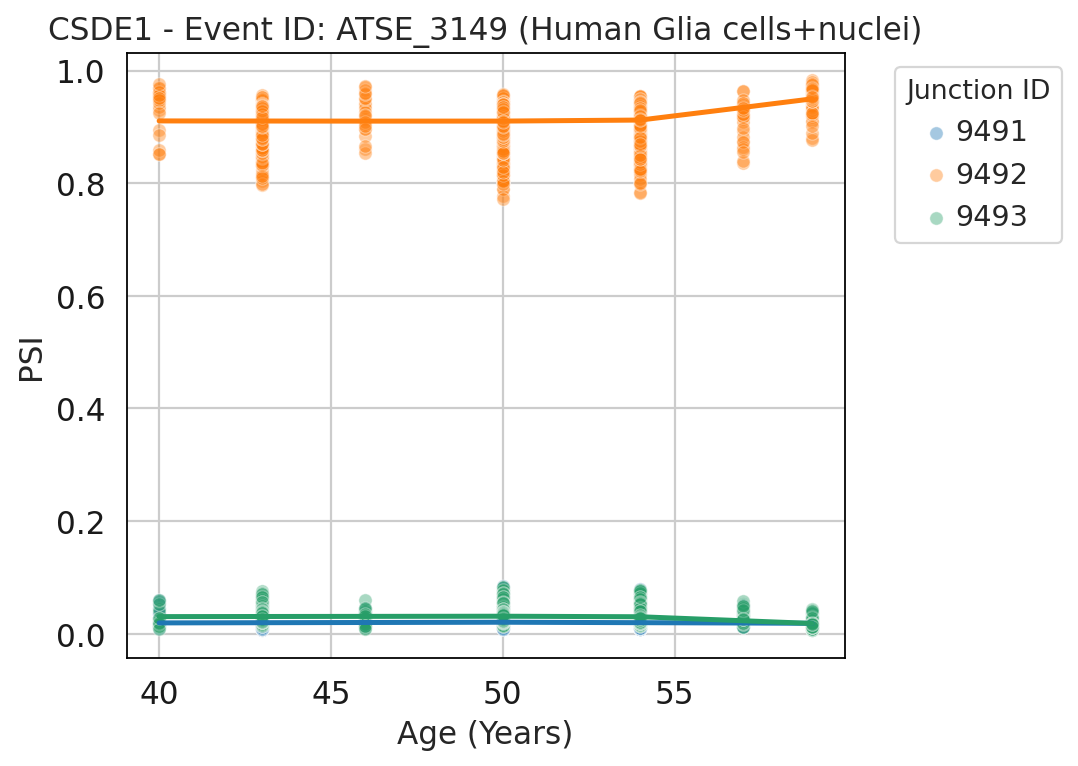

In [60]:
# 1. Subset to microglia
microglia = splice_adata[splice_adata.obs['broad_cell_type'] == 'GLIAL_CELL'].copy()

# 2. Extract CSDE1 junctions and their event_ids
csde1_junctions = microglia.var[microglia.var['gene_name'] == 'CSDE1'].copy()

# 3. Extract PSI matrix
psi = microglia[:, csde1_junctions.index].layers['PSI_CELLS']
if hasattr(psi, "toarray"):
    psi = psi.toarray()

# 4. Assemble tidy DataFrame
psi_df = pd.DataFrame(psi, columns=csde1_junctions.index, index=microglia.obs_names)
psi_df['age'] = microglia.obs['age'].values
psi_df['cell_id'] = microglia.obs['cell_id'].values

psi_long = psi_df.melt(id_vars=['age', 'cell_id'], var_name='junction_id', value_name='psi')
psi_long = psi_long.merge(
    csde1_junctions[['event_id']].reset_index().rename(columns={'index': 'junction_id'}),
    on='junction_id'
)

# 5. Plot one figure per event_id
event_ids = csde1_junctions['event_id'].unique()

for eid in sorted(event_ids):
    df = psi_long[psi_long['event_id'] == eid].dropna()

    plt.figure(figsize=(7, 5))

    # Loop through junctions in this event_id
    for junc_id, junc_df in df.groupby('junction_id'):
        # Scatter + trend line (lowess)
        sns.scatterplot(data=junc_df, x='age', y='psi', label=junc_id, alpha=0.4)
        sns.regplot(data=junc_df, x='age', y='psi', scatter=False, lowess=True)

    plt.title(f'CSDE1 - Event ID: {eid} (Human Glia cells+nuclei)')
    plt.xlabel('Age (Years)')
    plt.ylabel('PSI')
    plt.legend(title='Junction ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [59]:
microglia.var[microglia.var["event_id"] == "ATSE_3149"][["junction_id", "junction_id_index"]]

,junction_id,junction_id_index
9491,chr1_114736855_114737470_-,9491
9492,chr1_114736855_114737962_-,9492
9493,chr1_114737563_114737962_-,9493


In [51]:
atses = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/TMS_atse_file_unanno_also_2025-04-26_20-24-12.txt.gz"
atses = pd.read_csv(atses, sep="\t")
atses

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,transcript_types,annotation_status,perfect_match_5_prime,perfect_match_3_prime,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
0,ATSE_0,ENSG00000116254.18,CHD5,protein_coding,3,exon_skip,"protein_coding,nonsense_mediated_decay",both,"ENST00000262450.8,ENST00000496404.1","ENST00000262450.8,ENST00000475121.1,ENST000004...",...,1.0000,1.0000,0.6643,21799,32817,GT-AG,GT,AG,1.0,0.0
1,ATSE_0,ENSG00000116254.18,CHD5,protein_coding,3,exon_skip,"protein_coding,nonsense_mediated_decay",both,"ENST00000262450.8,ENST00000475121.1,ENST000004...","ENST00000262450.8,ENST00000496404.1",...,0.5165,0.5165,1.0000,22790,11772,GT-AG,GT,AG,1.0,0.0
2,ATSE_0,ENSG00000116254.18,CHD5,protein_coding,3,exon_skip,"protein_coding,nonsense_mediated_decay",both,"ENST00000262450.8,ENST00000475121.1,ENST000004...","ENST00000262450.8,ENST00000475121.1,ENST000004...",...,0.3357,0.3357,0.4835,32817,22790,GT-AG,GT,AG,1.0,0.0
3,ATSE_1,ENSG00000116254.18,CHD5,protein_coding,2,alternative_5_prime,nonsense_mediated_decay,unannotated,NaN,NaN,...,0.5008,0.5008,1.0000,1945,974,GT-AG,GT,AG,NaN,13.0
4,ATSE_1,ENSG00000116254.18,CHD5,protein_coding,2,alternative_5_prime,nonsense_mediated_decay,unannotated,NaN,NaN,...,1.0000,1.0000,0.4992,971,1945,GT-AG,GT,AG,NaN,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24340,ATSE_8691,ENSG00000115009.13,CCL20,protein_coding,2,alternative_3_prime,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000646475.1,ENST00000358813.5,ENST000004...",ENST00000358813.5,...,1.0000,0.5218,1.0000,501696,261773,GT-AG,GT,AG,0.0,1.0
24341,ATSE_8691,ENSG00000115009.13,CCL20,protein_coding,2,alternative_3_prime,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000646475.1,ENST00000358813.5,ENST000004...","ENST00000409189.7,ENST00000489160.1",...,1.0000,0.4782,1.0000,501696,239923,GT-AG,GT,AG,0.0,1.0
24342,ATSE_8692,ENSG00000123342.16,MMP19,protein_coding,3,exon_skip,"protein_coding,retained_intron,nonsense_mediat...",both,"ENST00000322569.9,ENST00000547685.5,ENST000005...","ENST00000322569.9,ENST00000547685.5,ENST000005...",...,1.0000,1.0000,0.8722,206115,236308,GT-AG,GT,AG,1.0,0.0
24343,ATSE_8692,ENSG00000123342.16,MMP19,protein_coding,3,exon_skip,"protein_coding,retained_intron,nonsense_mediat...",both,"ENST00000322569.9,ENST00000547685.5,ENST000005...","ENST00000322569.9,ENST00000547685.5,ENST000005...",...,0.8207,0.8207,1.0000,168420,138227,GT-AG,GT,AG,1.0,0.0


In [52]:
event_ids

['ATSE_3147', 'ATSE_3148', 'ATSE_3149', 'ATSE_3146']
Categories (8360, object): ['ATSE_0', 'ATSE_2', 'ATSE_3', 'ATSE_4', ..., 'ATSE_8688', 'ATSE_8690', 'ATSE_8691', 'ATSE_8692']

Imports successful!
Found 44 unique transcripts


                   transcript_name                 transcript_type  \
ENST00000261443.9        CSDE1-201                  protein_coding   
ENST00000339438.10       CSDE1-202                  protein_coding   
ENST00000358528.9        CSDE1-203                  protein_coding   
ENST00000369530.5        CSDE1-204                  protein_coding   
ENST00000438362.7        CSDE1-205                  protein_coding   
ENST00000483030.2        CSDE1-206                 retained_intron   
ENST00000524652.2        CSDE1-208                 retained_intron   
ENST00000525132.1        CSDE1-209                  protein_coding   
ENST00000529046.6        CSDE1-212                  protein_coding   
ENST00000530886.5        CSDE1-214                  protein_coding   
ENST00000534699.5        CSDE1-217                  protein_coding   
ENST00000610726.5        CSDE1-218                  protein_coding   
ENST00000684913.1        CSDE1-219                  protein_coding   
ENST00000685676.1   

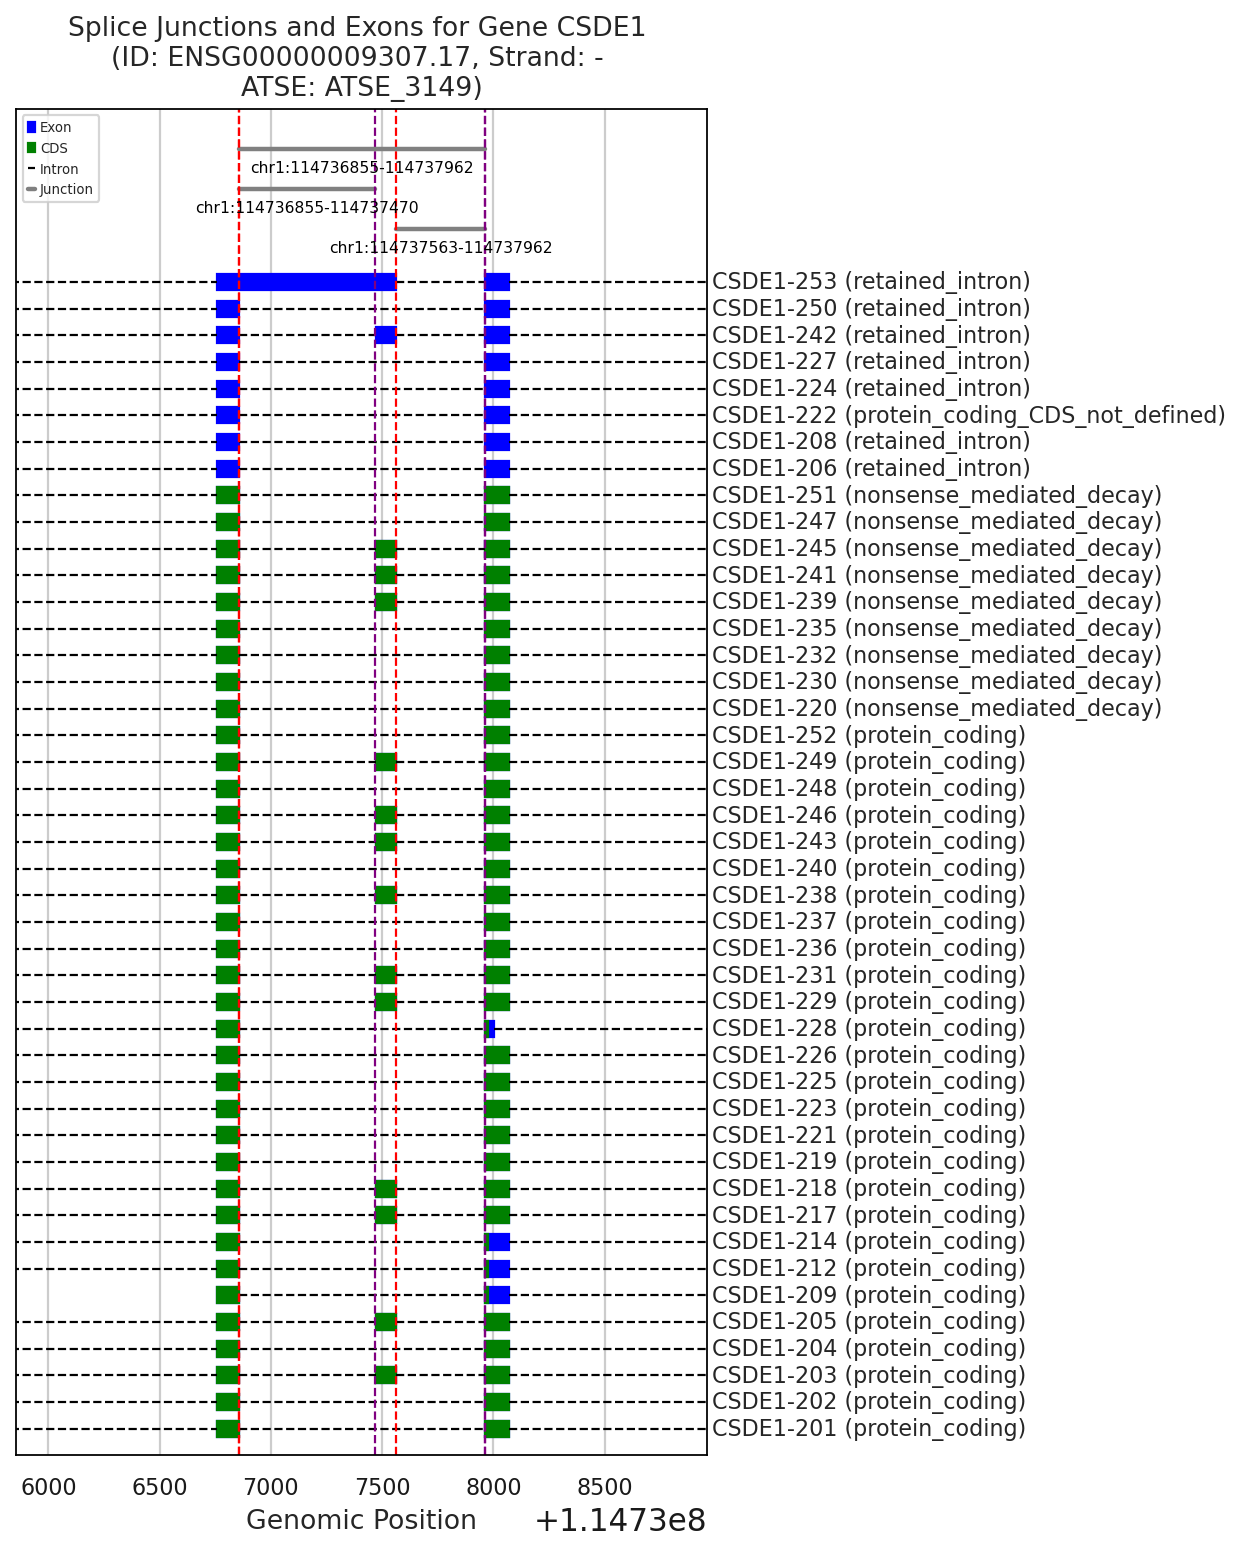

In [56]:
# Import necessary libraries
import pandas as pd
import os
import sys
import pandas as pd
import numpy as np
from typing import List, Set

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

atse_event = "ATSE_3149"

# Create a copy of the subset to avoid SettingWithCopyWarning
juncs = atses[atses["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)

# Example usage:
unique_transcripts = extract_unique_transcripts(juncs)
print(f"Found {len(unique_transcripts)} unique transcripts")

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=8, trans_height=0.2, show_usage=False, show_junc_lines=True, filename="test.pdf")

In [ ]:
# Get coverage per cell and compare with perplexity 
from scipy.sparse import issparse

# First confirm cell_id_clean order is the same
# Then add "library_size" column based on total coverage from raw counts in ge_adata add to both anndatasets use length_norm
common_cells = ge_adata.obs["cell_id_clean"].isin(splice_adata.obs["cell_id_clean"])
print(len(common_cells))
assert np.all(ge_adata.obs["cell_id_clean"].values == splice_adata.obs["cell_id_clean"].values), "Mismatch in cell_id_clean order"

# 3. Compute library size from length-normalized counts
length_norm = ge_adata.layers["length_norm"]
if issparse(length_norm):
    lib_size = np.asarray(length_norm.sum(axis=1)).flatten()
else:
    lib_size = length_norm.sum(axis=1)

ge_adata.obs["library_size"] = lib_size
splice_adata.obs["library_size"] = lib_size  # matching order guaranteed

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

# Extract data
perplexity = splice_adata.obs["perplexity"]
library_size = splice_adata.obs["library_size"]

# Drop any NaNs (safety)
valid = (~perplexity.isna()) & (~library_size.isna())
perplexity = perplexity[valid]
library_size = library_size[valid]
print(perplexity)

# Compute correlations
spearman_rho, spearman_p = spearmanr(library_size, perplexity)
pearson_rho, pearson_p = pearsonr(library_size, perplexity)

# Create scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=library_size, y=perplexity, s=10, alpha=0.5)

# Annotate with correlation values
plt.title(f"Perplexity vs. Library Size\n"
          f"Spearman ρ = {spearman_rho:.2f}, p = {spearman_p:.1e} | "
          f"Pearson r = {pearson_rho:.2f}, p = {pearson_p:.1e}")
plt.xlabel("Library Size (length-normalized)")
plt.ylabel("Perplexity")
plt.tight_layout()
plt.show()


In [ ]:
ge_adata

In [ ]:
splice_adata

In [ ]:
accuracies, models, label_encoder, coefficients_dfs_age = logistic_regression_feature_prediction(
    splice_adata=splice_adata,
    gene_expression_adata=ge_adata,
    feature="age",
    K=30,
    n_pcs=30,
    covariate_column="tissue",
    test_size=0.2
)

print(accuracies)

In [ ]:
accuracies, models, label_encoder, coefficients_dfs = logistic_regression_feature_prediction(
    splice_adata=splice_adata,
    gene_expression_adata=ge_adata,
    feature="cell_type_grouped",
    K=30,
    n_pcs=30,
    covariate_column="tissue",
    test_size=0.2
)

print(accuracies)

### Differential Splicing Analysis 

In [ ]:
# Get top variable junctions from PSI_df
top_junctions = PSI_df.sort_values(by="PSI_variance", ascending=False).head(20000).junction_id_index.values

In [ ]:
results = ds.analyze_all_factors_psi(psi_samples, top_junctions, min_effect_size=0.25)

all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    
    # Append to list
    all_results.append(significance_df)

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]

In [ ]:
# convert splice_adata.var["junction_id_index"] to dtype int64
splice_adata.var["junction_id_index"] = splice_adata.var["junction_id_index"].astype("int64")
# Merge with adata.var using junction_id_index
final_df = final_df.merge(splice_adata.var, on="junction_id_index")
# filter just significant junctions
final_df = final_df[final_df["significant"]]
# calculate perplexity based on number of factors a junction is significant in
perplexity = final_df.groupby("junction_id_index")["factor_idx"].nunique()
final_df["perplexity"] = final_df["junction_id_index"].map(perplexity)
# sort by perplexity
final_df.sort_values(by="perplexity", ascending=False)

### Annotating splicing programs
- how much variance do they explain within cell type versus between cell type? similarly tissue, sex, mouse.id... 
- how are these factors or splicing programs influenced by RBP gene expression? 
- how do these factors relate to aging genes? 

### Get latent representation of RBPs

In [ ]:
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

# Step 1: Mark which genes are RBPs
ge_adata.var["RBP_gene"] = ge_adata.var["mouse_gene_name"].isin(rbps["mouse_gene_name"])

# Step 2: Subset the expression matrix to RBP genes only
rbp_mask = ge_adata.var["RBP_gene"].values
expr = ge_adata.X[:, rbp_mask].toarray()

# Step 3: Filter out genes with all-zero expression
non_zero_genes = np.any(expr != 0, axis=0)
expr = expr[:, non_zero_genes]

# Step 4: Get the gene names *after filtering*
rbp_gene_names = ge_adata.var["mouse_gene_name"].values[rbp_mask][non_zero_genes]

# Step 5: Perform PCA to get latent representation of RBPs
pca = PCA(n_components=10)
rbp_latent = pca.fit_transform(expr)

# Step 1: Wrap factor activity in a DataFrame
n_factors = splice_adata.obsm["X_PHI"].shape[1]
factor_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"],
    index=splice_adata.obs_names,
    columns=[f"factor_{i}" for i in range(n_factors)]
)

# Now correlate with factor_activity
for i in range(rbp_latent.shape[1]):
    for factor in factor_df.columns:
        rho, _ = spearmanr(rbp_latent[:, i], factor_df[factor])

# Each row = RBP gene, each column = PCA component
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=rbp_gene_names,
    columns=[f"PCA{i+1}" for i in range(pca.n_components_)]
)

# Create a dictionary to store top RBPs per PCA
top_rbps_dict = {}

for pc in pca_loadings.columns:
    top_rbps = pca_loadings[pc].abs().sort_values(ascending=False).head(10)
    top_rbps_dict[pc] = top_rbps.index.tolist()

# Convert to a DataFrame
top_rbps_df = pd.DataFrame.from_dict(top_rbps_dict, orient='index')
top_rbps_df.columns = [f"Top_RBP_{i+1}" for i in range(top_rbps_df.shape[1])]

# Build correlation matrix: rows = PCA components, columns = splicing factors
cor_matrix = pd.DataFrame(index=[f"PCA{i+1}" for i in range(rbp_latent.shape[1])],
                          columns=factor_df.columns)

for i in range(rbp_latent.shape[1]):
    for factor in factor_df.columns:
        rho, _ = spearmanr(rbp_latent[:, i], factor_df[factor])
        cor_matrix.loc[f"PCA{i+1}", factor] = rho

# Convert to float type (currently might be object)
cor_matrix_rbp = cor_matrix.astype(float)

In [ ]:
# Create clustermap
g = sns.clustermap(
    cor_matrix_rbp,
    cmap="vlag",
    center=0,
    figsize=(10, 6),
    annot=False,
    # Show all tick marks
    xticklabels=True,
    cbar_kws={"label": "Correlation"}
)

# Set the title and axis labels
g.fig.suptitle("Correlation Between RBP PCs \nand Splicing Programs", y=1)
g.ax_heatmap.set_xlabel("Splicing Factors")
g.ax_heatmap.set_ylabel("RBP PCA Components")

plt.tight_layout()
plt.show()

In [ ]:
# Flatten the table and count gene appearances
all_rbps = top_rbps_df.values.flatten()
rbp_counts = pd.Series(all_rbps).value_counts()
# Create a new DataFrame with same shape, storing count of appearances
rbp_color_matrix = top_rbps_df.copy()

for col in rbp_color_matrix.columns:
    rbp_color_matrix[col] = rbp_color_matrix[col].map(rbp_counts)

plt.figure(figsize=(13, 6))
sns.heatmap(
    rbp_color_matrix.astype(float),  # use appearance counts for coloring
    annot=top_rbps_df.values,        # show original gene names
    fmt="",                          # no numeric format, just text
    cmap="YlGnBu",                   # or any other colormap
    cbar_kws={"label": "# of PCs RBP Appears In"},
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Top RBPs per PCA Component (colored by how often they appear)")
plt.xlabel("Top RBPs")
plt.ylabel("PCA Component")
plt.tight_layout()
plt.show()

### Get latent representation of Aging Genes

In [ ]:
# Step 1: Mark which genes are RBPs
ge_adata.var["Aging_gene"] = ge_adata.var["mouse_gene_name"].isin(combined_genes)

# Step 2: Subset the expression matrix to RBP genes only
aging_mask = ge_adata.var["Aging_gene"].values
expr = ge_adata.X[:, aging_mask].toarray()

# Step 3: Filter out genes with all-zero expression
non_zero_genes = np.any(expr != 0, axis=0)
expr = expr[:, non_zero_genes]

# Step 4: Get the gene names *after filtering*
aging_gene_names = ge_adata.var["mouse_gene_name"].values[aging_mask][non_zero_genes]

# Step 5: Perform PCA to get latent representation of RBPs
pca = PCA(n_components=10)
aging_latent = pca.fit_transform(expr)

# Step 1: Wrap factor activity in a DataFrame
n_factors = splice_adata.obsm["X_PHI"].shape[1]
factor_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"],
    index=splice_adata.obs_names,
    columns=[f"factor_{i}" for i in range(n_factors)]
)

# Step 8: Correlation matrix between Aging PCs and splicing factors
cor_matrix = pd.DataFrame(index=[f"Aging_PC{i+1}" for i in range(aging_latent.shape[1])],
                          columns=factor_df.columns)

for i in range(aging_latent.shape[1]):
    for factor in factor_df.columns:
        rho, _ = spearmanr(aging_latent[:, i], factor_df[factor])
        cor_matrix.loc[f"Aging_PC{i+1}", factor] = rho

cor_matrix_aging = cor_matrix.astype(float)

# Each row = RBP gene, each column = PCA component
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=aging_gene_names,
    columns=[f"Aging_PC{i+1}" for i in range(pca.n_components_)]
)

# Create a dictionary to store top RBPs per PCA
top_aging_genes_dict = {}
for pc in pca_loadings.columns:
    top_genes = pca_loadings[pc].abs().sort_values(ascending=False).head(10)
    top_aging_genes_dict[pc] = top_genes.index.tolist()

top_aging_df = pd.DataFrame.from_dict(top_aging_genes_dict, orient='index')
top_aging_df.columns = [f"Top_Gene_{i+1}" for i in range(top_aging_df.shape[1])]

In [ ]:
# Create clustermap
g = sns.clustermap(
    cor_matrix_aging,
    cmap="vlag",
    center=0,
    figsize=(10, 6),
    annot=False,
    # Show all tick marks
    xticklabels=True,
    cbar_kws={"label": "Correlation"}
)

# Set the title and axis labels
g.fig.suptitle("Correlation Between Aging Gene PCs \nand Aging Programs", y=1)
g.ax_heatmap.set_xlabel("Splicing Factors")
g.ax_heatmap.set_ylabel("Aging PCs")

plt.tight_layout()
plt.show()

In [ ]:
# Flatten the table and count gene appearances
all_genes = top_aging_df.values.flatten()
gene_counts = pd.Series(all_genes).value_counts()

# Create a new DataFrame with same shape, storing count of appearances
gene_color_matrix = top_aging_df.copy()
for col in gene_color_matrix.columns:
    gene_color_matrix[col] = gene_color_matrix[col].map(gene_counts)

# Plot the heatmap
plt.figure(figsize=(13, 6))
sns.heatmap(
    gene_color_matrix.astype(float),         # Color intensity = frequency
    annot=top_aging_df.values,               # Show gene names
    fmt="",                                  # Show as text
    cmap="YlGnBu",                           # You can try others like "viridis", "coolwarm"
    cbar_kws={"label": "# of PCs Gene Appears In"},
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Top Aging Genes per PCA Component (colored by frequency across PCs)")
plt.xlabel("Top Genes")
plt.ylabel("Aging PCA Component")
plt.tight_layout()
plt.show()


### For every factor, I want to give it a cell type score (perplexity? global vs cell type specific < 10 or 5 cell types active, aging score (overall association with aging) and RBP factor activity score)

In [ ]:
# These are coefficients for predicting major cell type groups adjusted for Tissue!
splice_cell_type_coefs = coefficients_dfs["splicing"]

# These are coefficients for predicting age adjusted for Tissue! (three main age groups, 3m, 18m, 24m)
splice_coefficients_dfs_age = coefficients_dfs_age["splicing"]

# ---- 1. Aging Score ----
# First, select only the factor columns from coefficients table 
factor_cols = [col for col in splice_coefficients_dfs_age.columns if col.startswith("factor_")]
age_coef_factors = splice_coefficients_dfs_age[factor_cols]

def classify_trajectory(values):
    v3, v18, v24 = values  # Coefs for 3m, 18m, 24m

    # Compute correlation
    age_points = [3, 18, 24]
    coefs = [v3, v18, v24]
    spearman_corr, _ = spearmanr(age_points, coefs)
    pearson_corr, _ = pearsonr(age_points, coefs)

    # Classify shape of trajectory
    if v3 < v18 < v24:
        label = "Increasing"
    elif v3 > v18 > v24:
        label = "Decreasing"
    elif v3 < v18 > v24:
        label = "Up-then-down"
    elif v3 > v18 < v24:
        label = "Down-then-up"
    elif np.allclose([v3, v18, v24], v3, atol=0.1):
        label = "Flat"
    else:
        label = "Dynamic"

    return pd.Series([label, spearman_corr, pearson_corr])

# Apply across columns (factors), rows are ages
trajectory_df = age_coef_factors.loc[["3m", "18m", "24m"]].apply(classify_trajectory, axis=0).T

# Add column names
trajectory_df.columns = ["Aging_Trajectory", "Spearman_AgeCorr", "Pearson_AgeCorr"]

# Reset index to get Factor name
trajectory_df = trajectory_df.reset_index().rename(columns={"index": "Factor"})

# ---- 2. Cell Type Specificity Score ----
factor_cols_ct = [col for col in splice_cell_type_coefs.columns if col.startswith("factor_")]
cell_type_coefs = splice_cell_type_coefs[factor_cols_ct]

# Compute counts per factor
threshold = 2
cell_type_pos_activity = (cell_type_coefs > threshold).sum(axis=0)   # coef > +2
cell_type_neg_activity = (cell_type_coefs < -threshold).sum(axis=0)  # coef < -2
cell_type_total_activity = ((cell_type_coefs.abs() > threshold)).sum(axis=0)

# Specificity = inverse of total activity
cell_type_specificity = 1 / (1 + cell_type_total_activity)

# Make into a DataFrame
cell_type_activity_df = pd.DataFrame({
    "Factor": cell_type_coefs.columns,
    "CellType_PosActivity": cell_type_pos_activity.values,
    "CellType_NegActivity": cell_type_neg_activity.values,
    "CellType_TotalActivity": cell_type_total_activity.values,
    "CellType_Specificity": cell_type_specificity.values
})

# ---- 3. RBP Influence Score ----
# Here cor_matrix_rbp is assumed to be a DataFrame where columns are factors.
threshold_rbp = 0.3
rbp_score = (cor_matrix_rbp.abs() > threshold_rbp).sum(axis=0)

# ---- 4. Aging gene activity Influence Score ----
threshold_aging = 0.3
aging_score = (cor_matrix_aging.abs() > threshold_aging).sum(axis=0)

In [ ]:
age_coef_factors

In [ ]:
# First, convert the RBP and aging influence Series into DataFrames
rbp_df = rbp_score.reset_index()
rbp_df.columns = ["Factor", "RBP_Influence"]

aging_df = aging_score.reset_index()
aging_df.columns = ["Factor", "AgingGene_Influence"]

# Start merging
summary_df = trajectory_df \
    .merge(cell_type_activity_df, on="Factor", how="outer") \
    .merge(rbp_df, on="Factor", how="outer") \
    .merge(aging_df, on="Factor", how="outer")

summary_df = summary_df.sort_values("Factor").reset_index(drop=True)

In [ ]:
top_factors = summary_df.sort_values("AgingGene_Influence", ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_factors,
    x="AgingGene_Influence",
    y="Factor",
    hue="Aging_Trajectory",
    dodge=False,
    palette="viridis"
)
plt.title("Top Factors by Aging Gene Influence")
plt.xlabel("AgingGene Influence (PCs > |0.3|)")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()


In [ ]:
output_dir

In [ ]:
# Assume X_PHI and splice_adata are already defined
phi_df = pd.DataFrame(X_PHI, columns=[f"factor_{i}" for i in range(X_PHI.shape[1])])
phi_df["cell_type"] = splice_adata.obs["cell_type_grouped"].values

# Output list
explained_variances = []

# Loop over factors
for factor in phi_df.columns.drop("cell_type"):
    print(f"Processing factor: {factor}")
    values = phi_df[factor].values
    labels = phi_df["cell_type"].values

    total_var = np.var(values, ddof=1)
    group_df = pd.DataFrame({"value": values, "cell_type": labels})
    group_means = group_df.groupby("cell_type", observed=True)["value"].mean()
    group_medians = group_df.groupby("cell_type", observed=True)["value"].median()
    group_sizes = group_df.groupby("cell_type", observed=True).size()
    overall_mean = group_df["value"].mean()
    overall_median = group_df["value"].median()

    # Variance calculations
    between_var = np.sum((group_means - overall_mean) ** 2) / (len(group_means) - 1)
    between_var_median = np.sum((group_medians - overall_median) ** 2) / (len(group_medians) - 1)

    group_df["group_mean"] = group_df["cell_type"].map(group_means).astype(float)
    group_df["group_median"] = group_df["cell_type"].map(group_medians).astype(float)
    group_df["residual"] = group_df["value"] - group_df["group_mean"]
    group_df["residual_median"] = group_df["value"] - group_df["group_median"]

    within_var = np.var(group_df["residual"], ddof=1)
    within_var_median = np.var(group_df["residual_median"], ddof=1)

    # Variance explained here is specifically for cell type, representing how much of the factor activity variation 
    # is explained by differences between cell types
    explained_var = (between_var / (between_var + within_var))
    explained_var_median = (between_var_median / (between_var_median + within_var_median)) 

    explained_variances.append({
        "Factor": factor,
        "Explained_Variance": explained_var,
        "Explained_Variance_Median": explained_var_median,
        "Between_Variance": between_var,
        "Between_Variance_Median": between_var_median,
        "Within_Variance": within_var,
        "Within_Variance_Median": within_var_median,
        "Total_Variance": total_var
    })

    # Plot activity across cell types
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="cell_type", y="value", data=group_df, fliersize=1)
    plt.xticks(rotation=90)
    plt.title(f"{factor} distribution across cell types")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.savefig(os.path.join(downstream_analysis_dir, f"{factor}_activity.png"))
    plt.close()

    # Plot residuals
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="cell_type", y="residual", data=group_df, color="skyblue", fliersize=1)
    plt.xticks(rotation=90)
    plt.title(f"Residuals of {factor} by Cell Type")
    plt.xlabel("Cell Type")
    plt.ylabel("Residual Value")
    plt.tight_layout()
    plt.savefig(os.path.join(downstream_analysis_dir, f"{factor}_residuals.png"))
    plt.close()

How to intepret these variance values? 

- For factor_0, total variance is 0.018111. (Overall variability of the factor activity (phi) across all cells.) 
- For factor_0, between-group variance is 0.00907 — so roughly half of the total variance is due to cell type differences. (Variance between cell types — how much the mean activity per cell type differs from the overall mean.)
- For factor_0, within-group variance is 0.008536. (Variance within each cell type — how much individual cells vary from their group mean.)
- Interpretation: For factor_0, 51.5% of the variance is due to cell type differences, the rest is within-cell type

In [ ]:
# Final DataFrame
anova_df = pd.DataFrame(explained_variances)

# Order by Explained_Variance 
anova_df = anova_df.sort_values(by="Total_Variance", ascending=False)

# Plot Explained Variance
plt.figure(figsize=(12, 6))
sns.barplot(data=anova_df, x="Factor", y="Explained_Variance", color="steelblue")
plt.xticks(rotation=90)
plt.ylabel("Explained Variance")
plt.title("Explained Variance by Factor (Mean-based)")
plt.tight_layout()

# Save plot
plt.savefig(os.path.join(downstream_analysis_dir, "explained_variance_mean_based.png"))
plt.show()

# Plot Explained Variance (Median-based)
plt.figure(figsize=(12, 6))
sns.barplot(data=anova_df, x="Factor", y="Explained_Variance_Median", color="darkorange")
plt.xticks(rotation=90)
plt.ylabel("Explained Variance (Median)")
plt.title("Explained Variance by Factor (Median-based)")
plt.tight_layout()

# Save plot
plt.savefig(os.path.join(downstream_analysis_dir, "explained_variance_median_based.png"))
plt.show()

# Plot Explained Variance
plt.figure(figsize=(12, 6))
sns.barplot(data=anova_df, x="Factor", y="Total_Variance", color="steelblue")
plt.xticks(rotation=90)
plt.ylabel("Total Variance")
plt.title("Total Factor Variance")
plt.tight_layout()

# Save plot
plt.savefig(os.path.join(downstream_analysis_dir, "total_factor_variance.png"))
plt.show()


In [ ]:
anova_df

In [ ]:
# correlate total factor variance with PI_df 
PI_df["Factor"] = PI_df["Factor"].apply(lambda x: f"factor_{x}")
anova_df = anova_df.merge(PI_df)

In [ ]:
anova_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))

# Scatterplot
sns.scatterplot(data=anova_df, x="Explained_Variance", y="Total_Variance", color="purple")

# Axes labels
plt.xlabel("Explained Variance")
plt.ylabel("Total Variance")

# Annotate each point
for _, row in anova_df.iterrows():
    plt.annotate(
        text=row["Factor"],
        xy=(row["Explained_Variance"], row["Total_Variance"]),
        xytext=(row["Explained_Variance"] + 0.005, row["Total_Variance"] + 0.005),  # offset so labels don’t overlap points
        arrowprops=dict(arrowstyle="->", color='black', lw=0.8),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", edgecolor="gray", facecolor="white", alpha=0.5)
    )

plt.tight_layout()
plt.show()


In [ ]:
# PLot Explained variance vs PI
plt.figure(figsize=(6, 6))
sns.scatterplot(data=anova_df, x="Total_Variance", y="PI", color="steelblue")
plt.xlabel("Total Variance")
plt.ylabel("PI")

# plot Explained Variance vs PI
plt.figure(figsize=(6, 6))
sns.scatterplot(data=anova_df, x="Explained_Variance", y="PI", color="orange")
plt.xlabel("Explained Variance")
plt.ylabel("PI")

In [ ]:
# Plot Explained Variance
plt.figure(figsize=(12, 6))
sns.barplot(data=anova_df.sort_values(by="PI"), x="Factor", y="PI", color="orange")
plt.xticks(rotation=90)
plt.ylabel("PI")
plt.title("Learned Overall Activity (PI)")
plt.tight_layout()

# Save plot
plt.savefig(os.path.join(downstream_analysis_dir, "PI_factors.png"))
plt.show()

In [ ]:
# Merge with summary_df
summary_df = summary_df.merge(anova_df, on="Factor")
summary_df

In [ ]:
# Prepare data
viz_df = summary_df.set_index("Factor")[[
    "Pearson_AgeCorr",
    "CellType_Specificity",
    "RBP_Influence",
    "AgingGene_Influence",
    "Explained_Variance"
]]
viz_df_clean = viz_df.astype(float)

# Z-score normalization per annotation type (row-wise scaling)
viz_df_norm = pd.DataFrame(
    StandardScaler().fit_transform(viz_df_clean.T),  # scale across factors
    index=viz_df_clean.columns,                     # annotation types
    columns=viz_df_clean.index                      # factors
).T  # transpose back to original layout

# Plot normalized heatmap
g = sns.clustermap(
    viz_df_norm.T,
    cmap="coolwarm",
    center=0,
    row_cluster=True,
    col_cluster=True,
    figsize=(14, 8)
)

# Optional tweaks
plt.title("Splicing Factor Annotation \nHeatmap (Z-score Normalized)")
plt.tight_layout()
plt.show()


In [ ]:
rbp_latent_df = pd.DataFrame(rbp_latent, columns=[f"RBP_PC{i}" for i in range(rbp_latent.shape[1])])
aging_latent_df = pd.DataFrame(aging_latent, columns=[f"Aging_PC{i}" for i in range(aging_latent.shape[1])])
rbp_latent_df

In [ ]:
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.formula.api as smf

# Assume X_PHI and splice_adata are already defined
phi_df = pd.DataFrame(X_PHI, columns=[f"factor_{i}" for i in range(X_PHI.shape[1])])
phi_df["cell_type"] = splice_adata.obs["cell_type_grouped"].values
phi_df["tissue"] = splice_adata.obs["tissue"].values
phi_df["sex"] = splice_adata.obs["sex"].values
phi_df["mouse_id"] = splice_adata.obs["mouse.id"].values
phi_df["age"] = splice_adata.obs["age"].values # continuous age in months... 

# Add also RBP PCs 
rbp_latent_df = pd.DataFrame(rbp_latent, columns=[f"RBP_PC{i}" for i in range(rbp_latent.shape[1])])
phi_df = pd.concat([phi_df, rbp_latent_df], axis=1) # column names from RBP_PC0	RBP_PC1	RBP_PC2... 

# Add aging gene PCs
aging_latent_df = pd.DataFrame(aging_latent, columns=[f"Aging_PC{i}" for i in range(aging_latent.shape[1])])
phi_df = pd.concat([phi_df, aging_latent_df], axis=1) # column names from aging_latent_df Aging_PC0	Aging_PC1... 

rbp_covariates = [col for col in phi_df.columns if col.startswith("RBP_PC")]
aging_covariates = [col for col in phi_df.columns if col.startswith("Aging_PC")]

def run_variance_explained_analysis(data, covariates, interaction_terms=None):
    r2_scores = []
    anova_list = []

    for col in [c for c in data.columns if c.startswith("factor_")]:
        print(f"Processing factor: {col}")
        formula = f"{col} ~ " + " + ".join(covariates)
        if interaction_terms:
            formula += " + " + " + ".join(interaction_terms)
        model = smf.ols(formula, data=data).fit()
        r2_scores.append({'factor': col, 'r2': model.rsquared})
        print(f"R-squared for {col}: {model.rsquared:.4f}")

        # Add ANOVA breakdown
        anova = anova_lm(model, typ=2)  # type 2 sums of squares
        anova['factor'] = col
        anova_list.append(anova.reset_index())

    r2_df = pd.DataFrame(r2_scores)
    anova_df = pd.concat(anova_list)
    return r2_df, anova_df

covariates = (
    ['C(cell_type)', 'C(tissue)', 'C(sex)', 'C(mouse_id)', 'age']
    + rbp_covariates[0:3]
    + aging_covariates[0:3]
)

interaction_terms = ['C(cell_type):age']

r2_df, anova_df = run_variance_explained_analysis(phi_df, covariates, interaction_terms=interaction_terms)

# Pivot to wide format
anova_df_filtered = anova_df[anova_df['index'] != 'Residual']
anova_pivot = anova_df_filtered.pivot_table(
    index='factor',
    columns='index',
    values='sum_sq',
    aggfunc='first'
)

# Normalize to get proportion of variance explained
anova_prop = anova_pivot.div(anova_pivot.sum(axis=1), axis=0)

In [ ]:
# Get top covariate and explained variance for each factor
top_covariates = anova_prop.idxmax(axis=1)
top_values = anova_prop.max(axis=1)
top_summary_df = pd.DataFrame({
    'factor': anova_prop.index,
    'top_covariate': top_covariates,
    'explained_variance': top_values
})

print("\nDetailed breakdown (covariates explaining >5% of variance per factor):")
for factor, row in anova_prop.iterrows():
    print(f"\nFactor: {factor}")
    for covariate, value in row.items():
        if value > 0.5:  # Adjust threshold as needed
            print(f"  {covariate}: {value:.4f}")

In [ ]:
anova_prop

In [ ]:
# Make Heatmap Summary of Variance Explained
plt.figure(figsize=(15, 10))

# Create clustermap
cg = sns.clustermap(
    anova_prop,
    linewidths=0.5,
    xticklabels=True,
    yticklabels=True,
    z_score=0,             # Standardizes rows
    center=0,              # Center colormap at 0
    cmap="vlag",           # Diverging colormap (white at 0)
    figsize=(10, 10),
    cbar_kws={"label": "Z-scored"}
)

# Set the title and axis labels
cg.fig.suptitle("Proportion of variance in each \nfactor explained by covariates", y=1.05)
cg.ax_heatmap.set_xlabel("Covariate")
cg.ax_heatmap.set_ylabel("Factor")

plt.tight_layout()
plt.show()


In [ ]:
# Try a mixed effects model, hierarchical model cells nested within mice or tissues or cell type or both 

### Other stuff / visualization

In [ ]:
# Example usage:
ds.plot_psi_distribution(psi_samples, junction_idx=1, ref_factor=10)  

In [ ]:
juncs = atses[atses["event_id"]=="ATSE_20168"]
juncs["usage_ratio"] = juncs["total_score"]
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start, region_end, base_width=15, trans_height=2, show_usage=True, show_junc_lines=False)



In [ ]:
# Calculate entropy for each cell, ensuring numerical stability (avoid log(0))
PHI_safe = np.clip(PHI, 1e-10, 1)  # Prevent log(0) errors
entropy = -np.sum(PHI_safe * np.log(PHI_safe), axis=1)

# Calculate perplexity for each cell
perplexity = np.exp(entropy)

# Store results in `adata.obs`
adata.obs["perplexity"] = perplexity
adata.obs["entropy"] = entropy

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=adata.obs, x="perplexity", hue="age", bins=30, kde=True, element="step")

# Get median perplexity per age group
median_perplexity = adata.obs.groupby("age")["perplexity"].median()

# Assign distinct colors from the KDE curves to the median lines
palette = sns.color_palette("tab10", n_colors=len(median_perplexity))  # Use same color set as Seaborn
color_dict = dict(zip(median_perplexity.index, palette))  # Map age group to color

# Add median lines with matching colors
for age_group, median in median_perplexity.items():
    plt.axvline(median, color=color_dict[age_group], linestyle="--", linewidth=1.5, label=f"Median ({age_group})")

# Set x-axis ticks to 0, 2, 4, ...
plt.xticks(np.arange(0, max(perplexity) + 2, 2))

# Labels and title
plt.xlabel("Perplexity (Number of Factors Active)", fontsize=15)
plt.ylabel("Number of Cells", fontsize=15)

# Increase font size of xaxis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Ensure legend appears
plt.legend()

# Display the plot
plt.show()

In [ ]:
cell_type_1 = "GLIAL CELL"
cell_type_2 = None
all_ds_neuron = []

# Iterate over each junction index and compute differential splicing
for junction_id_index in tqdm(top_junctions, desc="Computing differential splicing"):
    try:
        ds_results = ds.compute_differential_splicing_groups(
            adata, psi_samples, phi_samples, junction_id_index, group_1=cell_type_1, group_2=cell_type_2, 
            groupby_column="cell_type_grouped", min_effect_size=0.1
        )
        all_ds_neuron.append(ds_results)
    except Exception as e:
        print(f"Error processing junction {junction_id_index}: {e}")

# Convert results into a DataFrame
df_all_ds_neuron = pd.DataFrame(all_ds_neuron)
df_all_ds_neuron_sig = ds.compute_junctions_significance_groups(df_all_ds_neuron, min_effect_size=0.1)
df_all_ds_neuron_sig["junction_id_index"] = df_all_ds_neuron_sig["junction_idx"]
# merge with adata.var using junction_id_index
df_all_ds_neuron_sig = df_all_ds_neuron_sig.merge(adata.var, on="junction_id_index")

In [ ]:
leaflet_model.bb_conc

In [ ]:
df_all_ds_neuron_sig.sort_values(by=["significant", "effect_size"], ascending=[False, False]).head()

In [ ]:
# Let's compare young versus the rest 
group1 = "3m"
group2 = "24m" 
young_vs_old = []
min_effect_size = 0.1

# Iterate over each junction index and compute differential splicing
for junction_id_index in tqdm(top_junctions, desc="Computing differential splicing"):
    try:
        ds_results = ds.compute_differential_splicing_groups(
            adata, psi_samples, phi_samples, junction_id_index, group_1=group1, group_2=group2, 
            groupby_column="age", min_effect_size=min_effect_size
        )
        young_vs_old.append(ds_results)
    except Exception as e:
        print(f"Error processing junction {junction_id_index}: {e}")

# Convert results into a DataFrame
df_young_vs_old = pd.DataFrame(young_vs_old)
df_young_vs_old_sig = ds.compute_junctions_significance_groups(df_young_vs_old, min_effect_size=min_effect_size)
df_young_vs_old_sig["junction_id_index"] = df_young_vs_old_sig["junction_idx"]
# merge with adata.var using junction_id_index
df_young_vs_old_sig = df_young_vs_old_sig.merge(adata.var, on="junction_id_index")

In [ ]:
adata.obs.age.value_counts()

In [ ]:
# use adata.layers["PSI_CELLS"] for junction 24461 to plot on top of umap 
junction_id_index = 24066
adata.obs["junction_activity"] = adata.layers["PSI_CELLS"][:, junction_id_index]

# visualize junction 24461 and factor 18 usage across cells side by side
sc.pl.umap(adata, color=["cell_type_grouped", "junction_activity"], wspace=0.9, size=8, ncols=1)

In [ ]:
# find KCNAB2 junctions
# gene_check = "Kcnab2"

adata.var[adata.var["gene_name"] == gene_check].annotation_status.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract relevant data
gene_junctions = adata.var[adata.var["gene_name"] == gene_check]
juncs = gene_junctions.junction_id.unique()
junc_inds = gene_junctions.junction_id_index.unique()
junction_ids = gene_junctions.junction_id.values
annotation_status = gene_junctions.annotation_status.values  # Extract annotation status
atse_labels = gene_junctions.event_id.values  # Group junctions by ATSE

# Append "_ATSE" to indices for informative column names
junc_inds_columns = [f"{junc_ind}_{junc_ind_ats}_{junction_id}" 
                     for junc_ind, junc_ind_ats, junction_id in zip(junc_inds, atse_labels, junction_ids)]

# Extract PSI values and create DataFrame
junc_activities = adata.layers["PSI_CELLS"][:, junc_inds]
junc_df = pd.DataFrame(junc_activities, columns=junc_inds_columns)
junc_df["cell_type"] = adata.obs["cell_type_grouped"]

# Compute summary statistics (mean, median, variance)
summary_stats = junc_df.groupby("cell_type").agg(["mean", "median", "var"])

# Extract each statistic separately
mean_df = summary_stats.xs("mean", axis=1, level=1)
median_df = summary_stats.xs("median", axis=1, level=1)
var_df = summary_stats.xs("var", axis=1, level=1)

# Get cell type counts and format labels with counts
cell_type_counts = adata.obs["cell_type_grouped"].value_counts()
formatted_labels = [f"{ctype} ({cell_type_counts[ctype]})" for ctype in mean_df.index]

# Define a color mapping for annotation status
unique_annotations = np.unique(annotation_status)
annotation_colors = sns.color_palette("Set2", len(unique_annotations))  # Generate distinct colors
annotation_color_dict = dict(zip(unique_annotations, annotation_colors))

# Assign colors to junctions based on their annotation status
column_colors = [annotation_color_dict[status] for status in annotation_status]

# Order junctions by ATSE grouping (preserve order within ATSE)
sorted_indices = np.argsort(atse_labels)  # Sort junctions by ATSE labels
sorted_columns = mean_df.columns[sorted_indices]
mean_df = mean_df[sorted_columns]
median_df = median_df[sorted_columns]
var_df = var_df[sorted_columns]

# Sort column colors accordingly
column_colors = [column_colors[i] for i in sorted_indices]

# Define function to plot clustermaps with annotations and correct clustering
def plot_clustermap(data, title):
    sns.set(font_scale=0.8)
    
    g = sns.clustermap(data, 
                       cmap="viridis", 
                       standard_scale=1, 
                       col_colors=column_colors,  # Annotation-based colors
                       #annot=True,  # Display values in cells
                       fmt=".1f",   # Format numbers to 2 decimal places
                       cbar_kws={'label': 'Junction Usage'})  # Colorbar label

    # Adjust y-axis labels to show all cell types
    # g.ax_heatmap.set_yticklabels(formatted_labels, rotation=0)
    
    plt.title(title)
    plt.show()

# Generate separate clustermaps
plot_clustermap(mean_df, f"Mean Junction Usage \nAcross Cell Types for {gene_check}")
plot_clustermap(median_df, f"Median Junction Usage \nAcross Cell Types for {gene_check}")
plot_clustermap(var_df, f"Variance of Junction Usage \nAcross Cell Types for {gene_check}")

# Show annotation legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=annotation_color_dict[ann], markersize=10, label=ann) for ann in unique_annotations]
plt.legend(handles=legend_patches, title="Annotation Status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

In [ ]:
importlib.reload(ja)

In [ ]:
atse_event = "ATSE_39312"
juncs = atses[atses["event_id"]==atse_event]
juncs["usage_ratio"] = juncs["total_score"]
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, atse_event,
                            transcript_data, splice_junctions, region_start, region_end, base_width=10, trans_height=0.4, show_usage=False, show_junc_lines=False, filename="test")


In [ ]:
atse_event = "ATSE_39311"
juncs = atses[atses["event_id"]==atse_event]
juncs["usage_ratio"] = juncs["total_score"]
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, atse_event,
                            transcript_data, splice_junctions, region_start, region_end, base_width=8, trans_height=0.6, show_usage=False, show_junc_lines=False, filename="test")



In [ ]:
atse_event = "ATSE_39310"
juncs = atses[atses["event_id"]==atse_event]
juncs["usage_ratio"] = juncs["total_score"]
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, atse_event,
                            transcript_data, splice_junctions, region_start, region_end, base_width=8, trans_height=0.6, show_usage=False, show_junc_lines=False, filename="test")



### How do expression PCs correlate with factor PCs?

In [ ]:
# subset gene expression to microglial cells
microglia_ge = ge_adata[ge_adata.obs["cell_type_grouped"] == "MICROGLIA"]
microglia_splicing = adata[adata.obs["cell_type_grouped"] == "MICROGLIA"]

In [ ]:
# first ensrue that microglia_ge and microglia_splicing have the same order of cells
assert np.all(microglia_ge.obs.index == microglia_splicing.obs.index)

In [ ]:
# Get the gene expression matrix PCs
X_microglia_ge = microglia_ge.obsm["X_pca"][:, :30]  # (n_cells, 10)
X_microglia_splicing = microglia_splicing.obsm["X_PHI"]  # (n_cells, n_factors)

# Compute correlation matrix (10 PCs by n_factors) and transpose to put PCs on x-axis
correlation_matrix = np.corrcoef(X_microglia_ge.T, X_microglia_splicing.T)[:30, 30:].T  # Shape is now (n_factors, 10)

# Define labels
factor_labels = [f"Factor {i}" for i in range(X_microglia_splicing.shape[1])]
pc_labels = [f"PC {i}" for i in range(30)]

# Create clustermap with adjusted orientation
g = sns.clustermap(correlation_matrix, cmap="coolwarm", center=0, annot=False,
                   xticklabels=pc_labels, yticklabels=factor_labels, figsize=(10, 8))

# Adjust label rotation and position
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)  # PCs now horizontal
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)  # Factors readable

# Highlight "Factor 10" in red
for label in g.ax_heatmap.get_yticklabels():
    if label.get_text() == "Factor 10":
        label.set_color("red")

# Set axis labels and title
g.ax_heatmap.set_xlabel("Gene Expression PCs")
g.ax_heatmap.set_ylabel("Splicing Factors")
#g.ax_heatmap.set_title("Correlation Matrix of Gene Expression PCs and \nSplicing Factors in Microglia")

plt.show()


In [ ]:
# Get the gene expression matrix PCs
X_ge = ge_adata.obsm["X_pca"][:, :30]  # (n_cells, 10)
X_splicing = adata.obsm["X_PHI"]  # (n_cells, n_factors)

# Compute correlation matrix (10 PCs by n_factors) and transpose to put PCs on x-axis
correlation_matrix = np.corrcoef(X_ge.T, X_splicing.T)[:30, 30:].T  # Shape is now (n_factors, 10)

# Define labels
factor_labels = [f"Factor {i}" for i in range(X_splicing.shape[1])]
pc_labels = [f"PC {i}" for i in range(30)]

# Create clustermap with adjusted orientation
g = sns.clustermap(correlation_matrix, cmap="coolwarm", center=0, annot=False,
                   xticklabels=pc_labels, yticklabels=factor_labels, figsize=(10, 8))

# Adjust label rotation and position
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)  # PCs now horizontal
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)  # Factors readable

# Highlight "Factor 10" in red
for label in g.ax_heatmap.get_yticklabels():
    if label.get_text() == "Factor 10":
        label.set_color("red")

# Set axis labels and title
g.ax_heatmap.set_xlabel("Gene Expression PCs")
g.ax_heatmap.set_ylabel("Splicing Factors")
g.ax_heatmap.set_title("Correlation Matrix of Gene Expression PCs and \nSplicing Factors in ALL cells")

plt.show()


In [ ]:
np.median(ge_adata[:, "Csde1"].X.toarray())

In [ ]:
ge_adata[:, "Csde1"].X.toarray().mean()

In [ ]:
# summarize Csd1 expression mean and median across every major cell type 
cell_types = ge_adata.obs["cell_type_grouped"].unique()
mean_expression = []
median_expression = []
for cell_type in cell_types:
    mean_expression.append(np.mean(ge_adata[ge_adata.obs["cell_type_grouped"] == cell_type, "Csde1"].X.toarray()))
    median_expression.append(np.median(ge_adata[ge_adata.obs["cell_type_grouped"] == cell_type, "Csde1"].X.toarray()))

# create a dataframe
Csde1_expression = pd.DataFrame({"cell_type": cell_types, "mean_expression": mean_expression, "median_expression": median_expression})
Csde1_expression.sort_values(by="median_expression")

In [ ]:
ge_adata.var_names

In [ ]:
# get Csde1 expression in microglia as violin plot by age group
plot_violin_by_cell_type(ge_adata, feature="gene", gene_name="Csde1", cell_type_column="cell_type_grouped", cell_type=None, group_column="age", size=(6,6))

In [ ]:
# Set parameters
num_cells = 5  # Number of cells
num_junctions = 3  # Number of junctions per cell
read_depth = 100  # Fixed total read depth per junction

# Define different concentration values (alpha + beta)
concentration_values = [3.5, 100, 1000]

# Initialize figure
fig, axes = plt.subplots(len(concentration_values), num_junctions, figsize=(12, 8), sharex=True, sharey=True)

# Simulate and plot distributions
for i, concentration in enumerate(concentration_values):
    alpha_beta = concentration / 2  # Split evenly (symmetric Beta prior)
    
    for j in range(num_junctions):
        # Sample mean success probability from Beta prior
        mu = np.random.beta(alpha_beta, alpha_beta, size=num_cells)  # One per cell
        
        # Sample junction reads from Beta-Binomial
        counts = [stats.betabinom.rvs(read_depth, alpha_beta, alpha_beta, size=1)[0] for _ in range(num_cells)]
        
        # Plot histogram
        ax = axes[i, j] if num_junctions > 1 else axes[i]
        ax.hist(counts, bins=np.arange(0, read_depth + 5, 5), alpha=0.7, color='blue', edgecolor='black')
        ax.set_title(f"Junction {j+1}, Concentration={concentration}")
        ax.set_xlabel("Spliced Reads")
        ax.set_ylabel("Frequency")
        
# Adjust layout and show
plt.tight_layout()
plt.show()
